In [ ]:
# Importing all the modules
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from astropy.io import fits
from scipy.interpolate import interp1d
from matplotlib import colors
import pandas as pd

In [ ]:
#Reading fits file
file = r"100pc_rvnotnull.fits" # file directory

hdul = fits.open(file) #unpacking the file

hdul.info() #inspecting the file's info

data = hdul[1].data # accessing data

source_id = data["SOURCE_ID_1"]

# Unpacking parallax and error
parallax = data["PARALLAX_1"]
parallax_err = data["PARALLAX_ERROR_1"]

# Unpacking PMRA and error
pmra = data["PMRA_1"]
pmra_err = data["PMRA_ERROR_1"]
# Unpacking PMDEC
pmdec = data["PMDEC_1"]
pmdec_err = data["PMDEC_ERROR_1"]

# Unpacking radial velocity and error
rv = data["radial_velocity"]
rv_err = data["radial_velocity_error"]

# Unpacking B_P - R_P colour
bp = data["PHOT_BP_MEAN_MAG_1"]
rp = data["PHOT_RP_MEAN_MAG_1"]
# Unpacking G mag
g_mag = data["PHOT_G_MEAN_MAG_1"] 

bp_rp = bp-rp # calculating bp-rp

# Masking the data as there are nans 
mask = np.isfinite(parallax) & np.isfinite(parallax_err) & (parallax > 0) & (parallax_err > 0) & np.isfinite(rv) & np.isfinite(rv_err) & np.isfinite(bp_rp) & np.isfinite(g_mag)

parallax = parallax[mask]
parallax_err = parallax_err[mask]
rv = rv[mask]
rv_err = rv_err[mask]
bp_rp = bp_rp[mask]
g_mag = g_mag[mask]
pmra = pmra[mask]     
pmra_err = pmra_err[mask]
pmdec = pmdec[mask]
pmdec_err = pmdec_err[mask]

# Finding the number of sources in the data set
print(f"Number of sources: {len(parallax)}")

Filename: /Users/ishnatripathi/Documents/environment/100pc_rvnotnull.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      16   (8043,)   uint8   
  1  Joined        1 BinTableHDU    252   167020R x 93C   [K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, I, D, D, 19A, A, E, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, 26A, 19A, D, D, D, D, D, D, D, D, 17A, E, E, E, E, E, E, 20A, E, E, E, E, E, E, E, E, K, 28A, D, D, D, D, D, D, D, D, D, E, E, E, E, E, E, E, E]   
Number of sources: 165507


/var/folders/ns/l7bjy9rj7w95wj_j633_8mmr0000gn/T/ipykernel_30564/3473311931.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


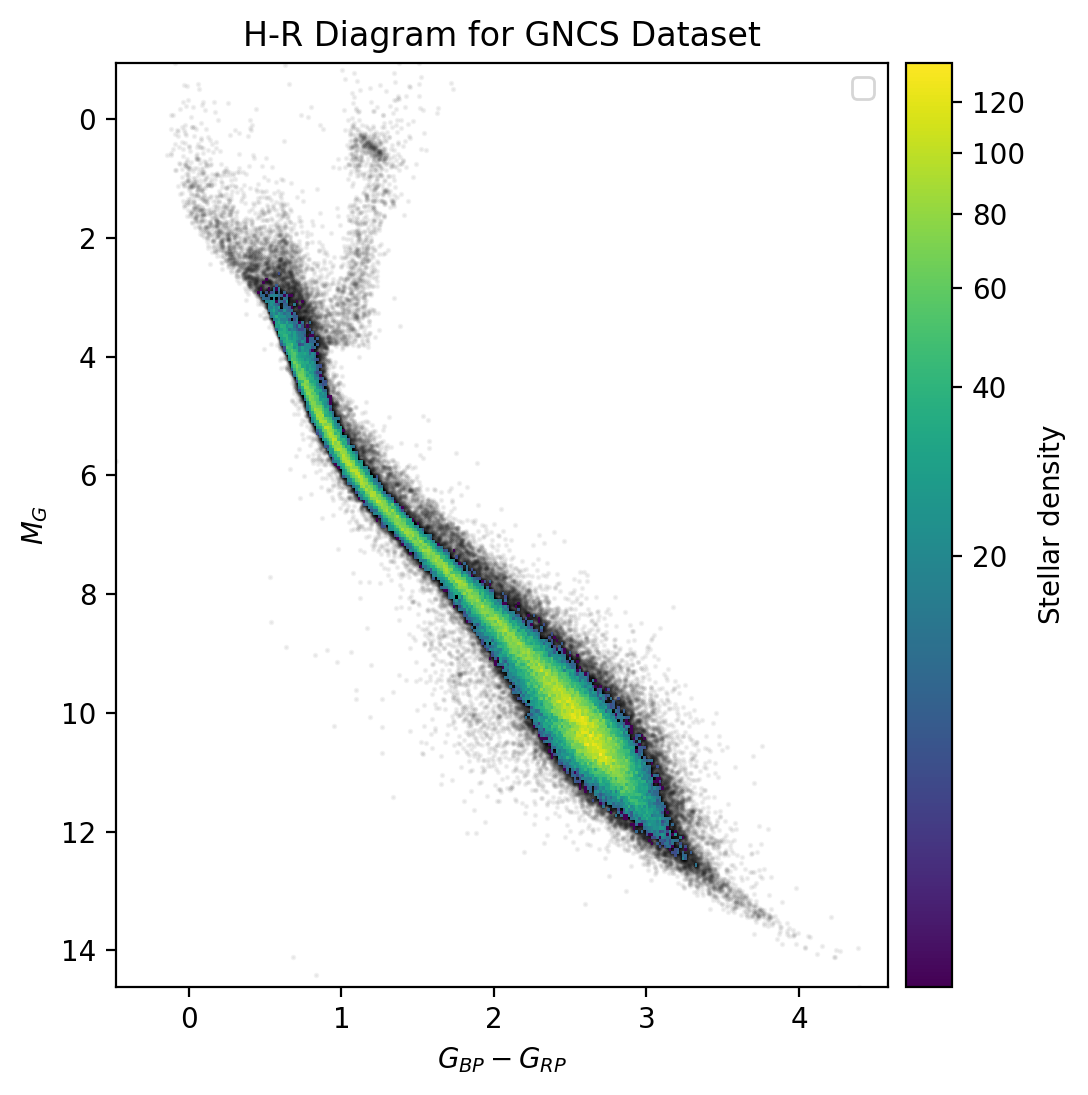

In [236]:
# HR Diagram
d = parallax / 1000 # distance
abs_mag = g_mag + 5 * np.log10(d) + 5 ## getting absolute magnitude 
mask = np.isfinite(abs_mag)
abs_mag = abs_mag[mask]

# Plotting the HR diagram
fig, ax = plt.subplots(figsize=(6, 6), dpi = 200)
# only show 2D-histogram for bins with more than 10 stars in them
h = ax.hist2d(bp_rp, abs_mag, bins=300, cmin=10, norm=colors.PowerNorm(0.3), zorder=0.7)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bp_rp, abs_mag, alpha=0.05, s=1, color='k', zorder=0)
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.legend()
plt.title("H-R Diagram for GNCS Dataset");plt.show()

# MISSING WHITE DWARFS
## REFERENCE: https://vlas.dev/post/gaia-dr2-hrd/

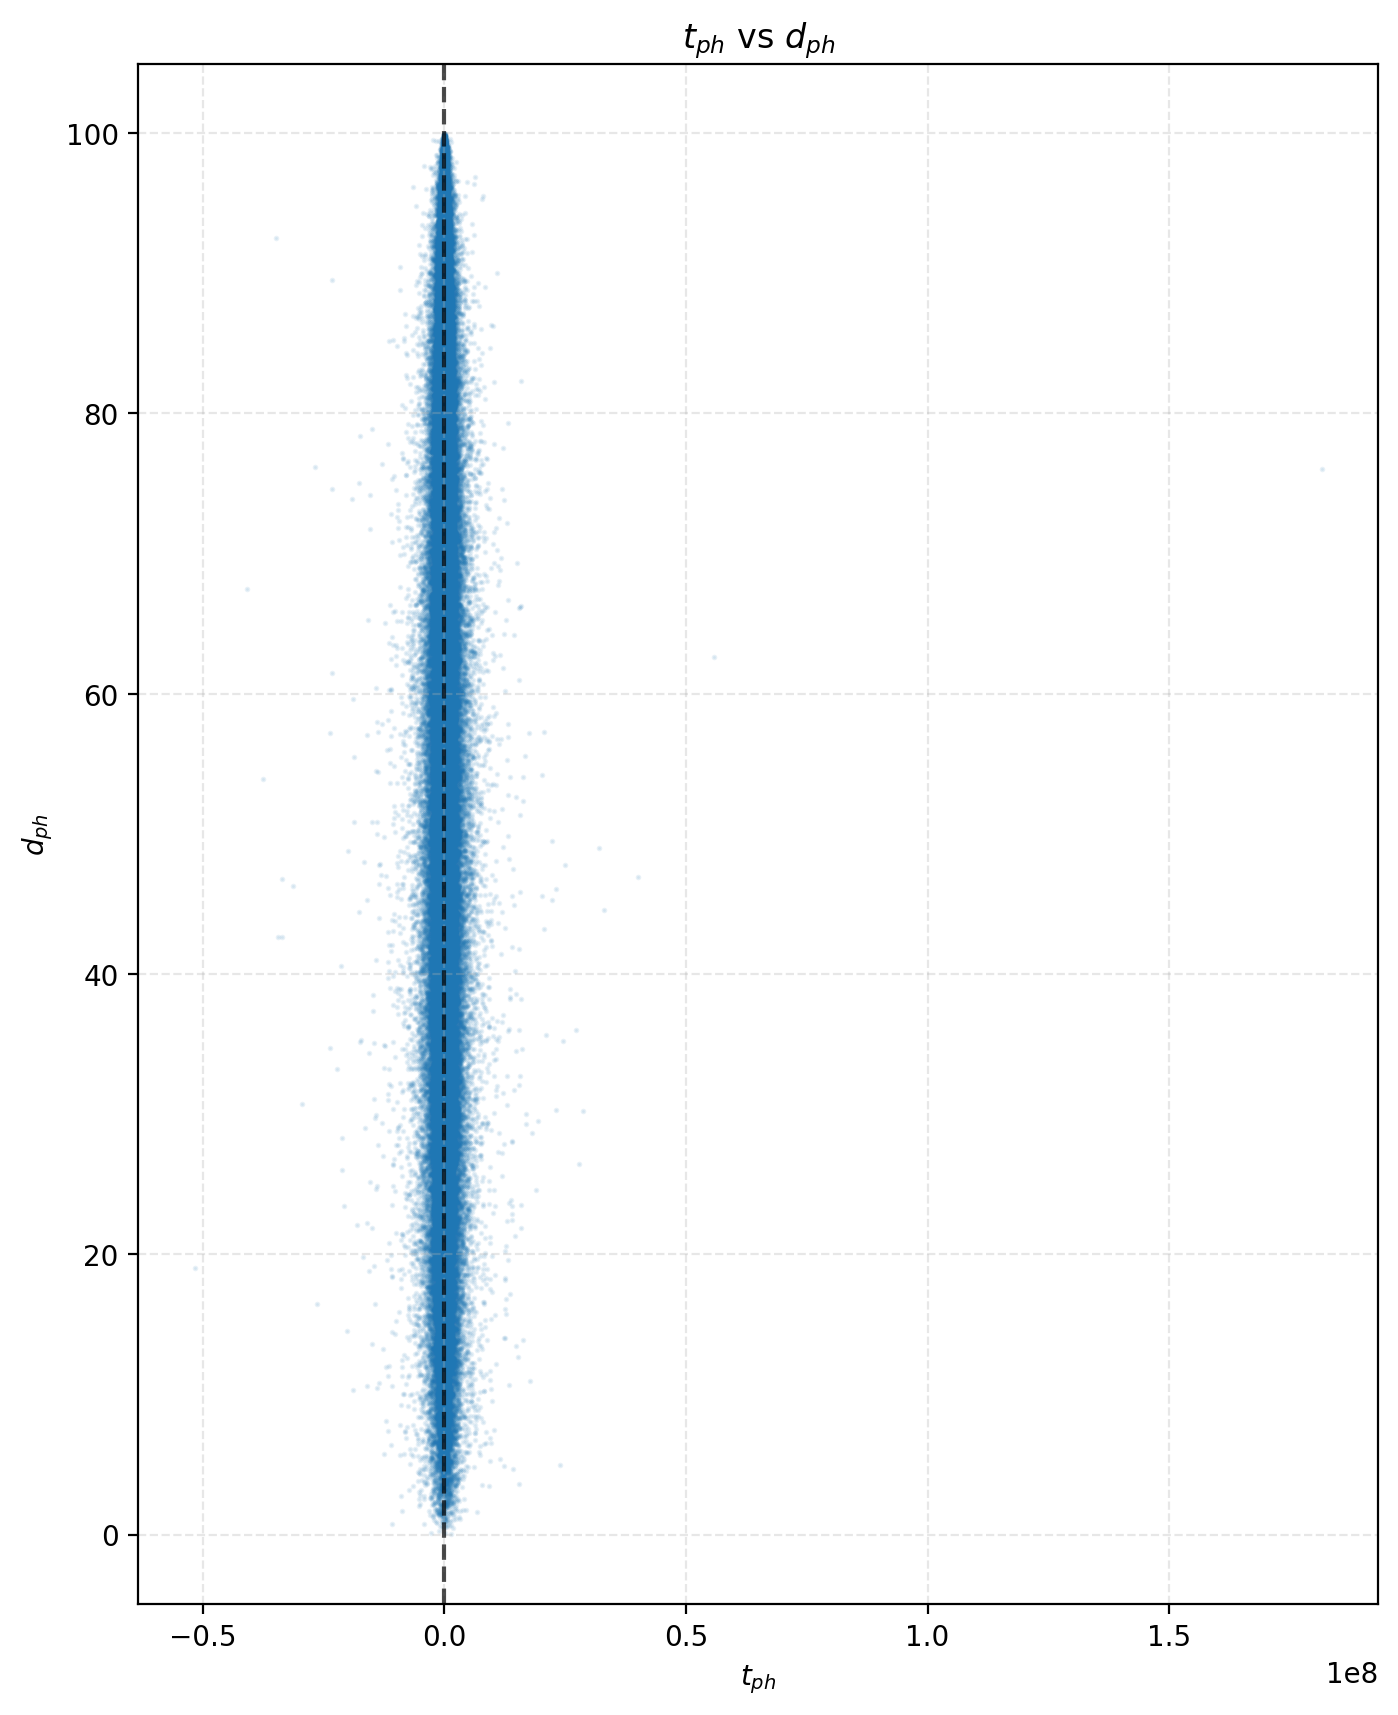

In [264]:
# Finding the time and distance at perihelion
c1 = 0.97779e9 # constant 1 [10^3 pc km^-1 yr^-1]
c2 = 4.74047 # constant 2 [AU km^-1 yr^-1]

vt = c2 * (np.sqrt((pmra**2) + (pmdec**2))/parallax) # transverse velocity (formula given in lab notes)
v = np.sqrt(vt**2 + rv**2) # total velocity

tph = -c1 * (1/parallax) * (rv / v**2) # time at perihelion
dph = (1e3) * (1/parallax) *(vt/v) # distance at perihelion

# Plotting t_ph vs d_ph
fig = plt.figure(figsize=(8, 10), dpi = 200)
plt.scatter(tph, dph, s = 1, alpha = 0.1)
plt.axvline(0, c = 'k', ls = '--', alpha = 0.7)
plt.title('$t_{ph}$ vs $d_{ph}$')
plt.xlabel('$t_{ph}$'); plt.ylabel('$d_{ph}$'); plt.grid(ls = '--', alpha = 0.3)
plt.show()

In [287]:
## Monte Carlo Sampling
def monte_carlo_sampling(p, perr, vr, vrerr, pmra, pmraerr, pmdec, pmdecerr, N = 1000):
    """
    INPUTS:
    - P: Parallax
    - Perr: Parallax error
    - PMRA: Proper motion right acension
    - PMRAerr: Proper motion right acension error
    - PMDEC: Proper motion declination
    - PMDECerr: Proper motion declination error
    - N = 1000 is the number of samples

    OUTPUTS:
    - TPH: Time at perihelion
    - DPH: Distance at perihelion
    - TPH_ERR: Error in time at perihelion
    - DPH_ERR: Error in Distance at perihelion
    """

    # Drawing the samples from a gaussian distribution
    ps = np.random.normal(p[:, None], perr[:, None], (len(p), N))
    rvs = np.random.normal(vr[:, None], vrerr[:, None], (len(vr), N))
    ras = np.random.normal(pmra[:, None], pmraerr[:, None],  (len(pmra), N))
    decs = np.random.normal(pmdec[:, None], pmdecerr[:, None], (len(pmdec), N))

    # Compute v_transvere and total velocity for each sample
    vts = c2 * np.sqrt(ras**2 + decs**2) / ps
    vs = np.sqrt(vts**2 + rvs**2)

    # Compute time and distance perihelion for each sample
    tphs = -c1 * (rvs / ps) / vs**2
    dphs = 1e3 * (vts / ps) / vs
    tph = np.mean(tphs, axis=1)
    tph_err = np.std(tphs, axis=1)
    dph = np.mean(dphs, axis=1)
    dph_err = np.std(dphs, axis=1)

    return tph, dph, tph_err, dph_err

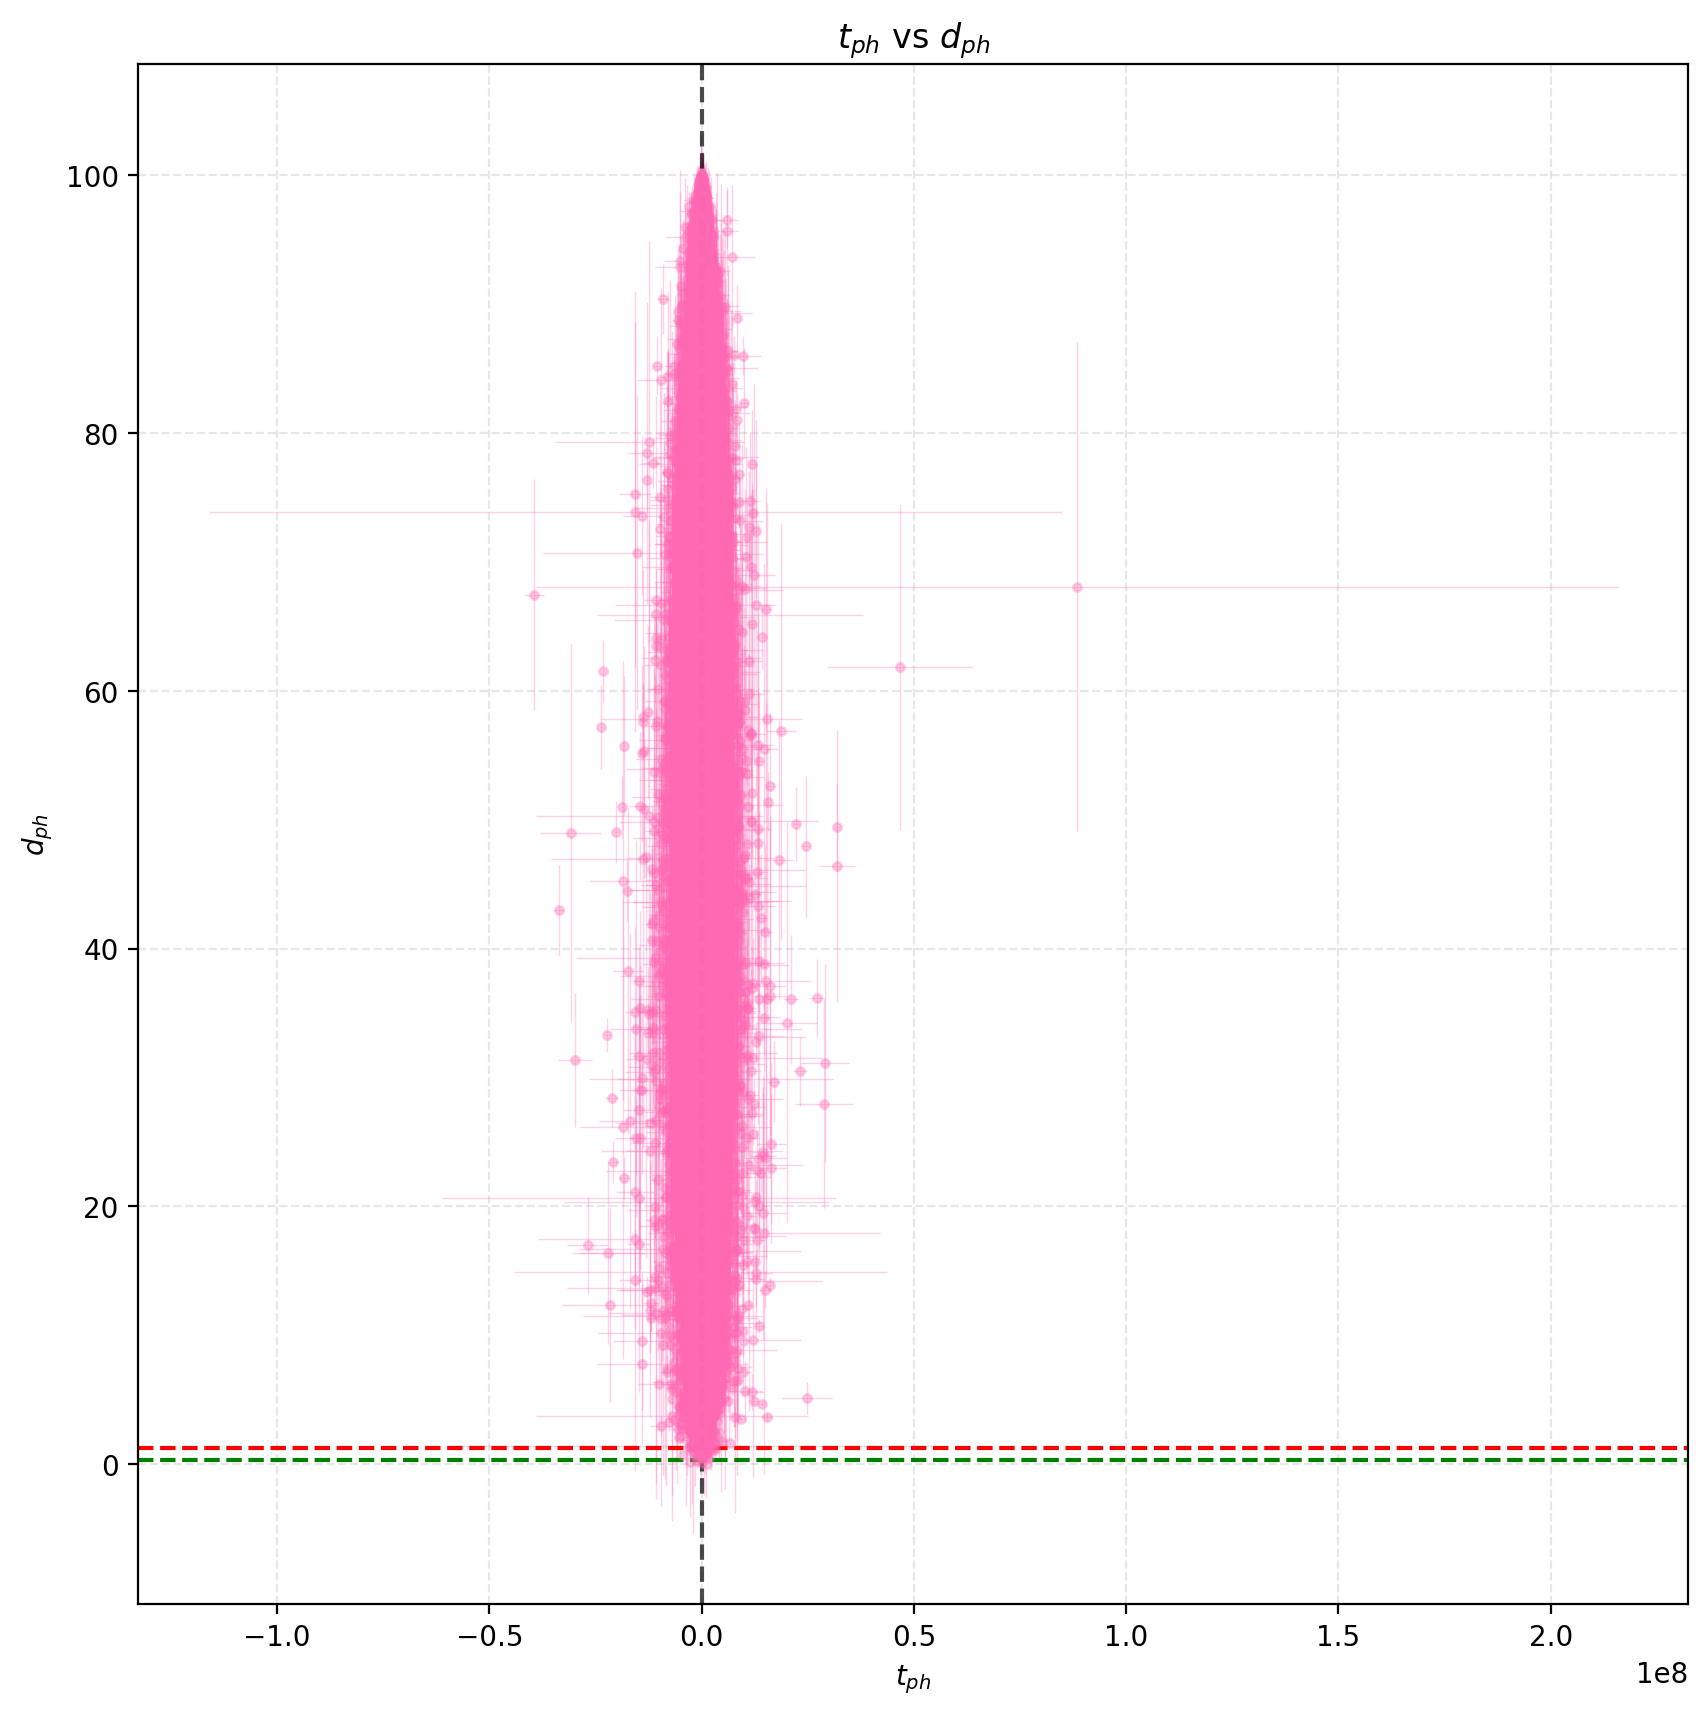

In [290]:
# 2 and 10 parsecs
tphs, dphs, tph_err, dph_err = monte_carlo_sampling(parallax, parallax_err, rv, rv_err, pmra, pmra_err, pmdec, pmdec_err, N=1000)

# Unpack the other columns
teff_raw = data['teff_gspphot']
bprp_raw = data['PHOT_BP_MEAN_MAG_1'] - data['PHOT_RP_MEAN_MAG_1']

# Mask the data
mas = np.isfinite(teff_raw) & np.isfinite(bprp_raw)
teff_gcns = teff_raw[mas]
bprp_gcns = bprp_raw[mas]

# Distance to Proxima centauri and the orrt cloud
proxima_centauri = 1.30197 #± 0.00003 parsecs
oort_cloud = 0.3 #parsecs

# Make masks for 2pc and 10 pc
mask_2pc = (dph < 2) & np.isfinite(dph) & np.isfinite(tph) & np.isfinite(dph_err) & np.isfinite(tph_err) & (dph_err / dph < 1.0)& (dph > 0)
mask_10pc = (dph < 10) & np.isfinite(dph) & np.isfinite(tph) & np.isfinite(dph_err) & np.isfinite(tph_err) & (dph_err / dph < 1.0)& (dph > 0)

fig = plt.figure(figsize=(10, 10), dpi = 200)
plt.errorbar(tphs, dphs, xerr=tph_err, yerr=dph_err, fmt='.', color='hotpink', alpha=0.3, linewidth=0.5)
plt.axvline(0, c = 'k', ls = '--', alpha = 0.7)
plt.title('$t_{ph}$ vs $d_{ph}$')
plt.xlabel('$t_{ph}$'); plt.ylabel('$d_{ph}$'); plt.grid(ls = '--', alpha = 0.3)
plt.axhline(proxima_centauri, c = 'r', ls = '--')
plt.axhline(oort_cloud, c = 'g', ls = '--')
plt.show()

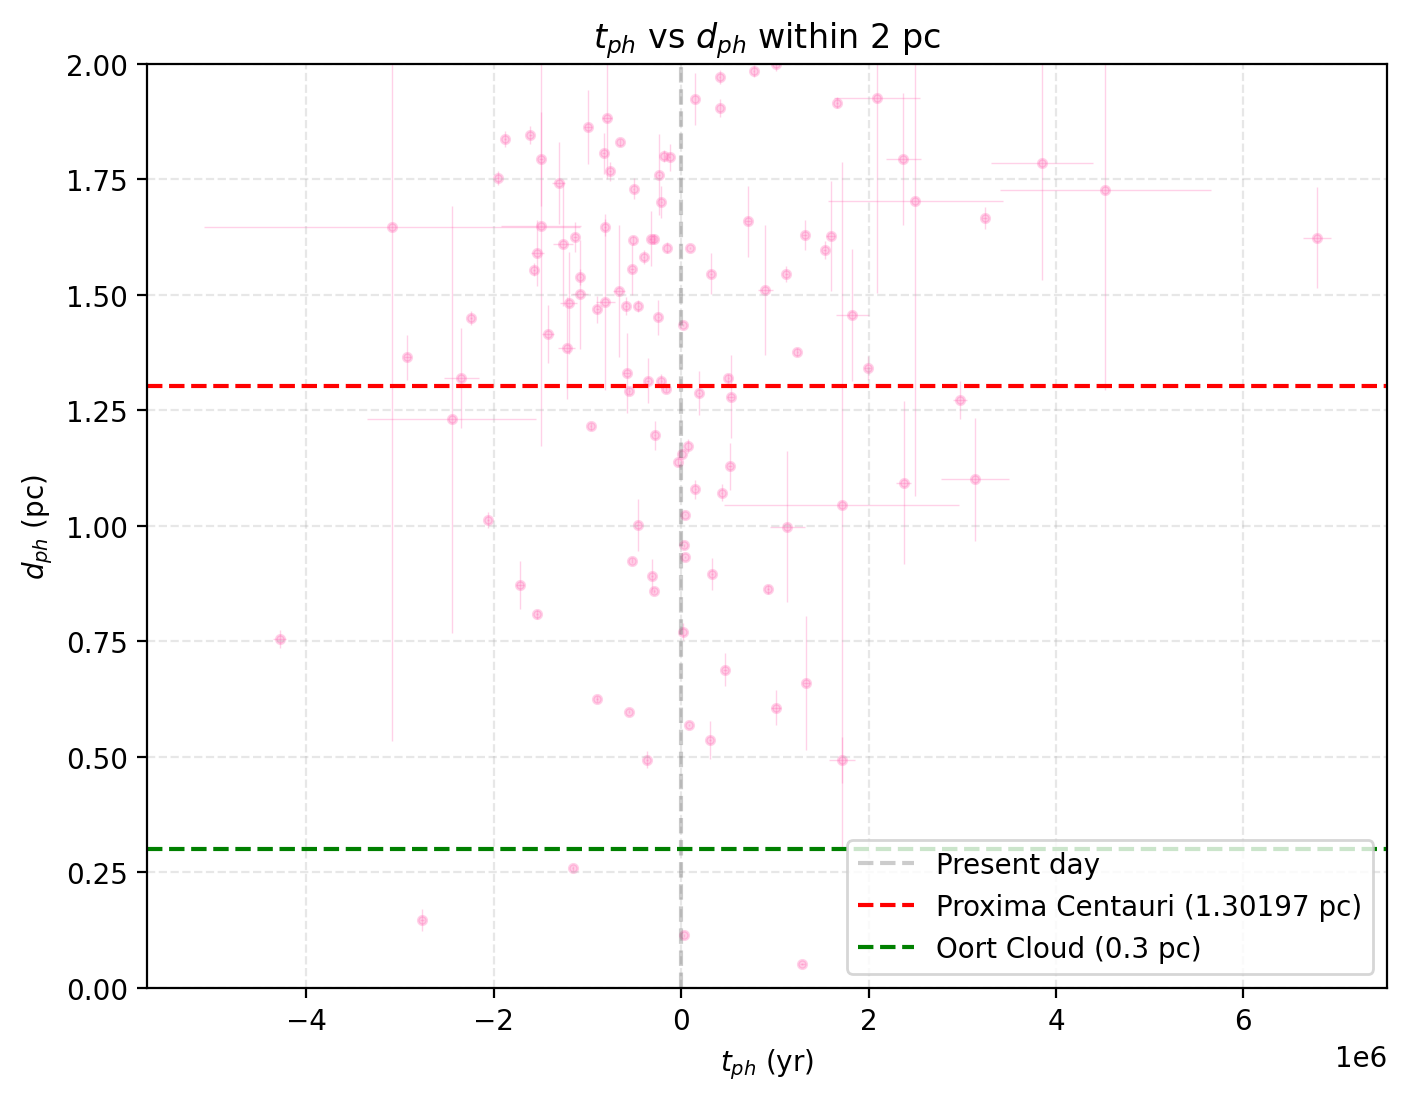

In [291]:
## Tph vs dph within 2 parsec
fig = plt.subplots(figsize=(8, 6), dpi=200)
plt.errorbar(tph[mask_2pc], dph[mask_2pc], xerr=tph_err[mask_2pc], yerr=dph_err[mask_2pc], fmt='.', color='hotpink', alpha=0.3, linewidth=0.5, zorder=0.3)
plt.axvline(0, c='k', ls='--', alpha=0.2, label='Present day')
plt.axhline(proxima_centauri, c='r', ls='--', label=f'Proxima Centauri ({proxima_centauri} pc)')
plt.axhline(oort_cloud, c='g', ls='--', label=f'Oort Cloud ({oort_cloud} pc)')
plt.ylim(0, 2)
plt.xlabel(r'$t_{ph}$ (yr)'); plt.ylabel(r'$d_{ph}$ (pc)')
plt.title(r'$t_{ph}$ vs $d_{ph}$ within 2 pc')
plt.legend(); plt.grid(ls='--', alpha=0.3); plt.show()

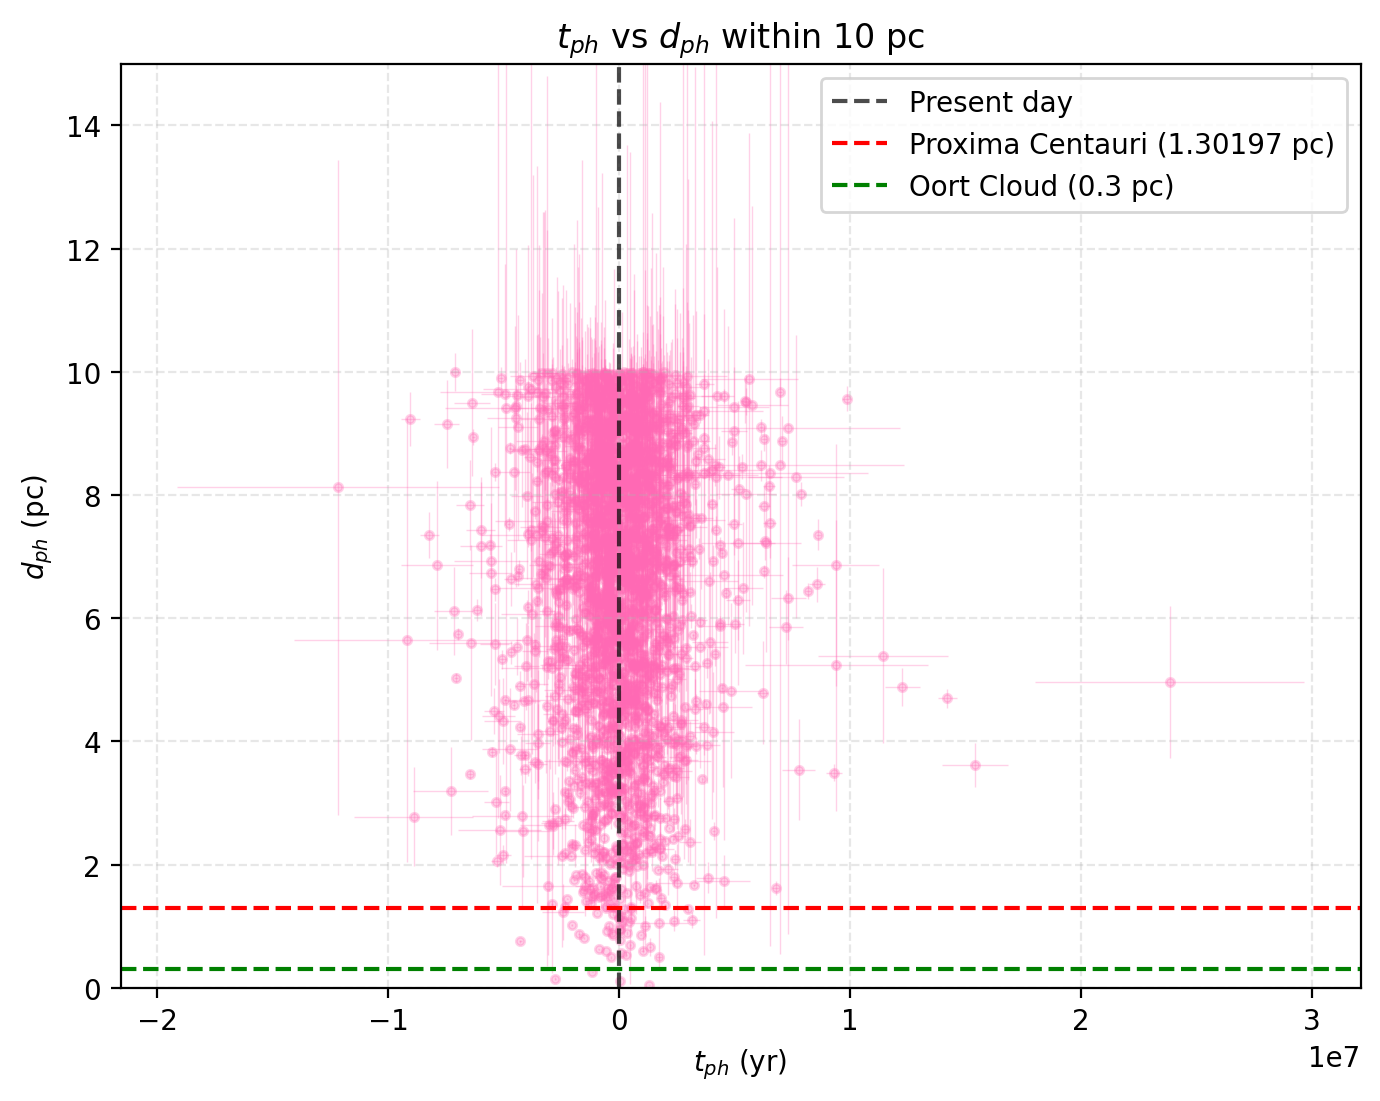

In [292]:
## Tph vs dph within 10 parsec
fig = plt.subplots(figsize=(8, 6), dpi=200)
plt.errorbar(tph[mask_10pc], dph[mask_10pc], xerr=tph_err[mask_10pc], yerr=dph_err[mask_10pc], fmt='.', color='hotpink', alpha=0.3, linewidth=0.5, zorder=1)
plt.axvline(0, c='k', ls='--', alpha=0.7, label='Present day')
plt.axhline(proxima_centauri, c='r', ls='--', label=f'Proxima Centauri ({proxima_centauri} pc)')
plt.axhline(oort_cloud, c='g', ls='--', label=f'Oort Cloud ({oort_cloud} pc)')
plt.xlabel(r'$t_{ph}$ (yr)'); plt.ylabel(r'$d_{ph}$ (pc)')
plt.title(r'$t_{ph}$ vs $d_{ph}$ within 10 pc')
plt.ylim(0,15)
plt.legend(); plt.grid(ls='--', alpha=0.3); plt.show()

In [242]:
# time window in 10 Myrs
in10Myrs = np.abs(tph) <= 10e6 # next 10 Myrs
close_proxima = np.sum((dph < proxima_centauri) & in10Myrs)  # when it will be closer than proxima
close_oort = np.sum((dph < oort_cloud) & in10Myrs) # when it will be closer than the oort cloud

print(f"Closer than Proxima Centauri: {close_proxima}")
print(f"Through Oort Cloud: {close_oort}")

Closer than Proxima Centauri: 171
Through Oort Cloud: 28


In [ ]:
## CREATE TABLE: finding the 10 closest stars to us
# Sort by tph within window
in10Myrs = (np.abs(tph) <= 10e6) & np.isfinite(dph) & np.isfinite(tph) # using a filter of 10myr to us to make life easier
dph_window = np.where(in10Myrs, dph, np.inf) # filter array
iclose = np.argsort(dph_window)[:10] # finding index of 10 closest

# Datasets for the 10 indices 
source_close  = data["SOURCE_ID_1"][iclose]
dph_close = dph[iclose]
dpherr_close = dph_err[iclose]
tph_close = tph[iclose]
tpherr_close = tph_err[iclose]
dclose = 1000 / parallax[iclose]
derrclose = (parallax_err[iclose] / parallax[iclose]**2) * 1000

## Printing the table using pandas dataframes
table = pd.DataFrame({
    'No.' : np.arange(1, 11), # Numbering the objects
    'Gaia DR3 Source ID' : source_close, # Source ID
    'Current Dist (pc)' : np.round(dclose, 5), # Getting the current distance
    'Current Dist err (pc)' : np.round(derrclose, 5), # Getting the uncertainity in the current distance
    'tph (yr)' : np.round(tph_close, 0).astype(int), # the time at perihelion and its assosicated error
    'tph err (yr)' : np.round(tpherr_close, 0).astype(int), # error
    'dph (pc)' : np.round(dph_close, 4), # the distance at perihelion and its associated error
    'dph err (pc)' : np.round(dpherr_close, 4)}) # error
table = table.set_index('No.')
print(table.to_string())

      Gaia DR3 Source ID  Current Dist (pc)  Current Dist err (pc)  tph (yr)  tph err (yr)  dph (pc)  dph err (pc)
No.                                                                                                               
1    2441630500517079808            4.84613                0.00111    117120            59    0.0213        0.0120
2    4810594479418041856            3.93393                0.00026    -15696             2    0.0270        0.0008
3    4472832130942575872            1.82823                0.00013     16175             2    0.0386        0.0008
4     762815470562110464            2.54613                0.00021     29234            11    0.0613        0.0015
5    3320184202856435840            8.11696                0.00112     19169           476    0.0673        0.0195
6    5853498713190525696            1.30197                0.00008     57783            21    0.0827        0.0042
7      76868614540049408            4.46963                0.00140    154378    

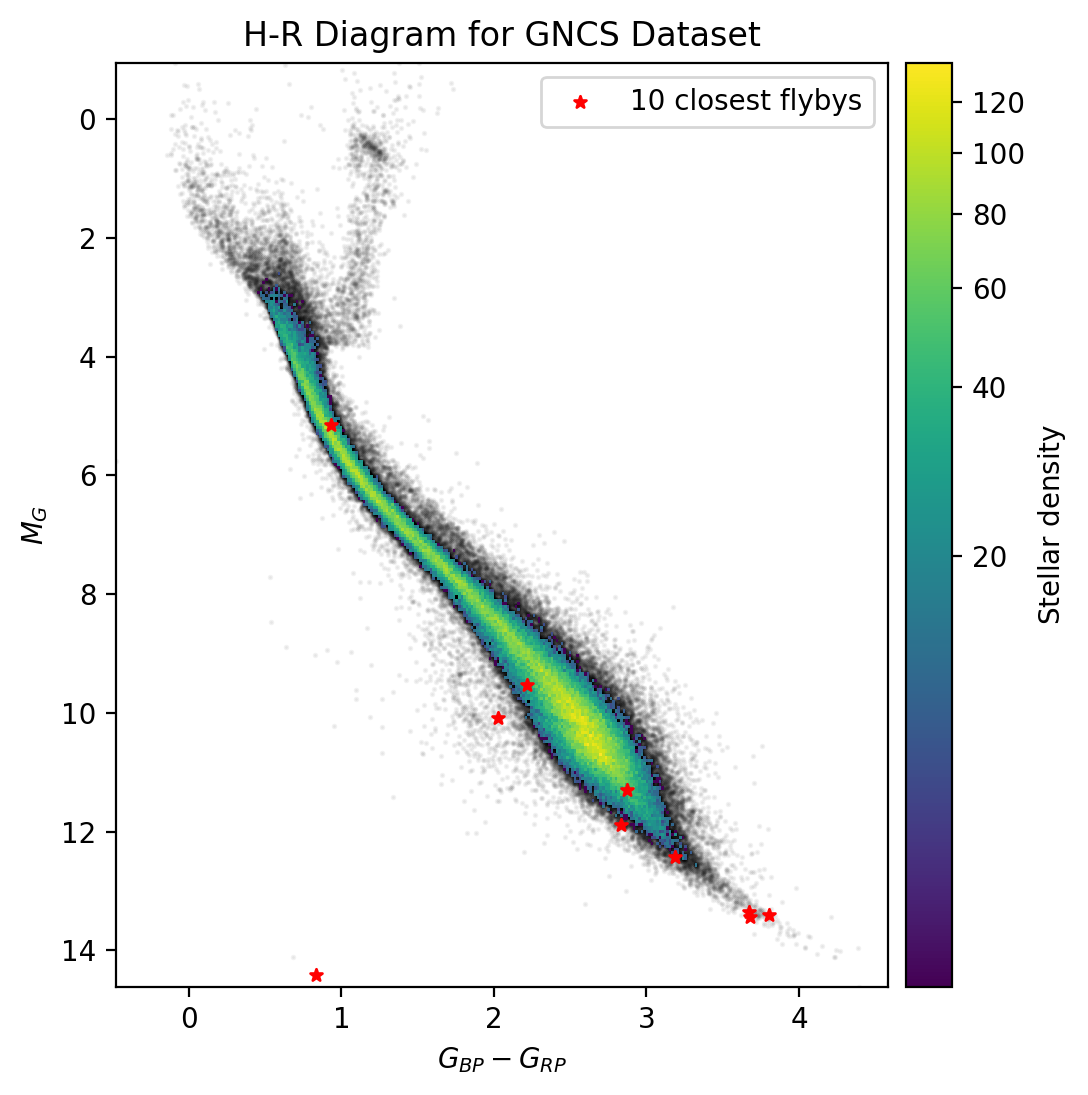


Spectral Types:
Source ID                 BP-RP      Spectral Type
-------------------------------------------------------------------------
2441630500517079808       3.675      M
4810594479418041856       2.027      M
4472832130942575872       2.834      M
762815470562110464        2.216      M
3320184202856435840       0.831      G
5853498713190525696       3.805      M
76868614540049408         3.188      M
5254061535106490112       3.681      M
3340477717172813568       2.870      M
4847957293278177024       0.933      G


In [ ]:
# Overplotted HR diagram with 10 closest objects
## extracting data again as they were overwriten above
bp = data["PHOT_BP_MEAN_MAG_1"]
rp = data["PHOT_RP_MEAN_MAG_1"]

bprp_hr= bp-rp

g_mag = data["PHOT_G_MEAN_MAG_1"] 
parallax_hr = data["PARALLAX_1"]

# Filter data for nans again 
mask_hr = np.isfinite(bprp_hr) & np.isfinite(g_mag) & np.isfinite(parallax_hr)
bprp_hr = bprp_hr[mask_hr]
g_mag = g_mag[mask_hr]
parallax_hr = parallax_hr[mask_hr]

# Getting absolute magnitude
abs_mag  = g_mag + 5 * np.log10(parallax_hr / 100)

# Plotting the HR diagram (same code as above)
fig, ax = plt.subplots(figsize=(6, 6), dpi = 200)
h = ax.hist2d(bprp_hr, abs_mag, bins=300, cmin=10, norm=colors.PowerNorm(0.3), zorder=0.7)
# fill the rest with scatter (set rasterized=True if saving as vector graphics)
ax.scatter(bprp_hr, abs_mag, alpha=0.05, s=1, color='k', zorder=0)

# Getting the 10 closest using their indices
bprp_hr = bprp_hr[iclose]
absmag_hr = abs_mag[iclose]

ax.scatter(bprp_hr, absmag_hr, s=20, c='red', zorder=2, label='10 closest flybys', marker = '*')
ax.invert_yaxis()
cb = fig.colorbar(h[3], ax=ax, pad=0.02)
ax.set_xlabel(r'$G_{BP} - G_{RP}$')
ax.set_ylabel(r'$M_G$')
cb.set_label(r"$\mathrm{Stellar~density}$")
plt.legend()
plt.title("H-R Diagram for GNCS Dataset");plt.show()

# Using the spt column in the Mamajek_realtions.txt, we get the rough guide
bprp_spec  = [-0.5, 0.3, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 4.0]
spt = [  'O/B',  'A',  'F',  'G', 'K',  'K/M', 'M', 'M']

# AI code to make nice table
print("\nSpectral Types:")
print(f"{'Source ID':<25} {'BP-RP':<10} {'Spectral Type'}")
print("-------------------------------------------------------------------------")
for i in range(10):
    bprp = bprp_hr[i]
    stype = spt[np.digitize(bprp, bprp_spec) - 1]
    print(f"{source_close[i]:<25} {bprp:<10.3f} {stype}")

### PART 3

In [ ]:
# New mamjek relations file
file_mamajek = r"Mamajek_relations.txt" # file directory

# Getting the header from the file
headers = np.loadtxt(file_mamajek, max_rows=1, dtype = str)

# Unpacking teff, bp_rp and mass
Teff, bp_rp, mass = np.loadtxt(file_mamajek, usecols = (1, 11, -2), unpack = True, dtype = str, skiprows = 23)
teff = np.array([float(x) if x != '...' else np.nan for x in Teff])
mass = np.array([float(x) if x != '...' else np.nan for x in mass])
bp_rp = np.array([float(x) if x != '...' else np.nan for x in bp_rp])

# Getting the GNCS data again
teff_gcns = data['teff_gspphot']
bp = data['PHOT_BP_MEAN_MAG_1']
rp = data['PHOT_RP_MEAN_MAG_1']
bprp_gcns = bp - rp
# Masking data to remove nans
mask_gcns = np.isfinite(teff_gcns) & np.isfinite(bprp_gcns)
teff_gcns = teff_gcns[mask_gcns]
bprp_gcns = bprp_gcns[mask_gcns]

/var/folders/ns/l7bjy9rj7w95wj_j633_8mmr0000gn/T/ipykernel_30564/2389501242.py:5: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=1`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  headers = np.loadtxt(file_mamajek, max_rows=1, dtype = str)
/var/folders/ns/l7bjy9rj7w95wj_j633_8mmr0000gn/T/ipykernel_30564/2389501242.py:8: UserWarning: Input line 108 contained no data and will not be counted towards `max_rows=50000`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23

'# Calculate these again\nvt = c2 * (np.sqrt((pmra**2) + (pmdec**2)) / parallax)  # ra, dec, parallax are already masked\nv  = np.sqrt(vt**2 + rv**2) # rv is already masked'

<>:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
<>:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
/var/folders/ns/l7bjy9rj7w95wj_j633_8mmr0000gn/T/ipykernel_30564/110987772.py:4: SyntaxWarning: "\o" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\o"? A raw string is also an option.
  plt.xlabel('$T_{eff}$ (K)'); plt.ylabel('Mass ($M_\odot$)')


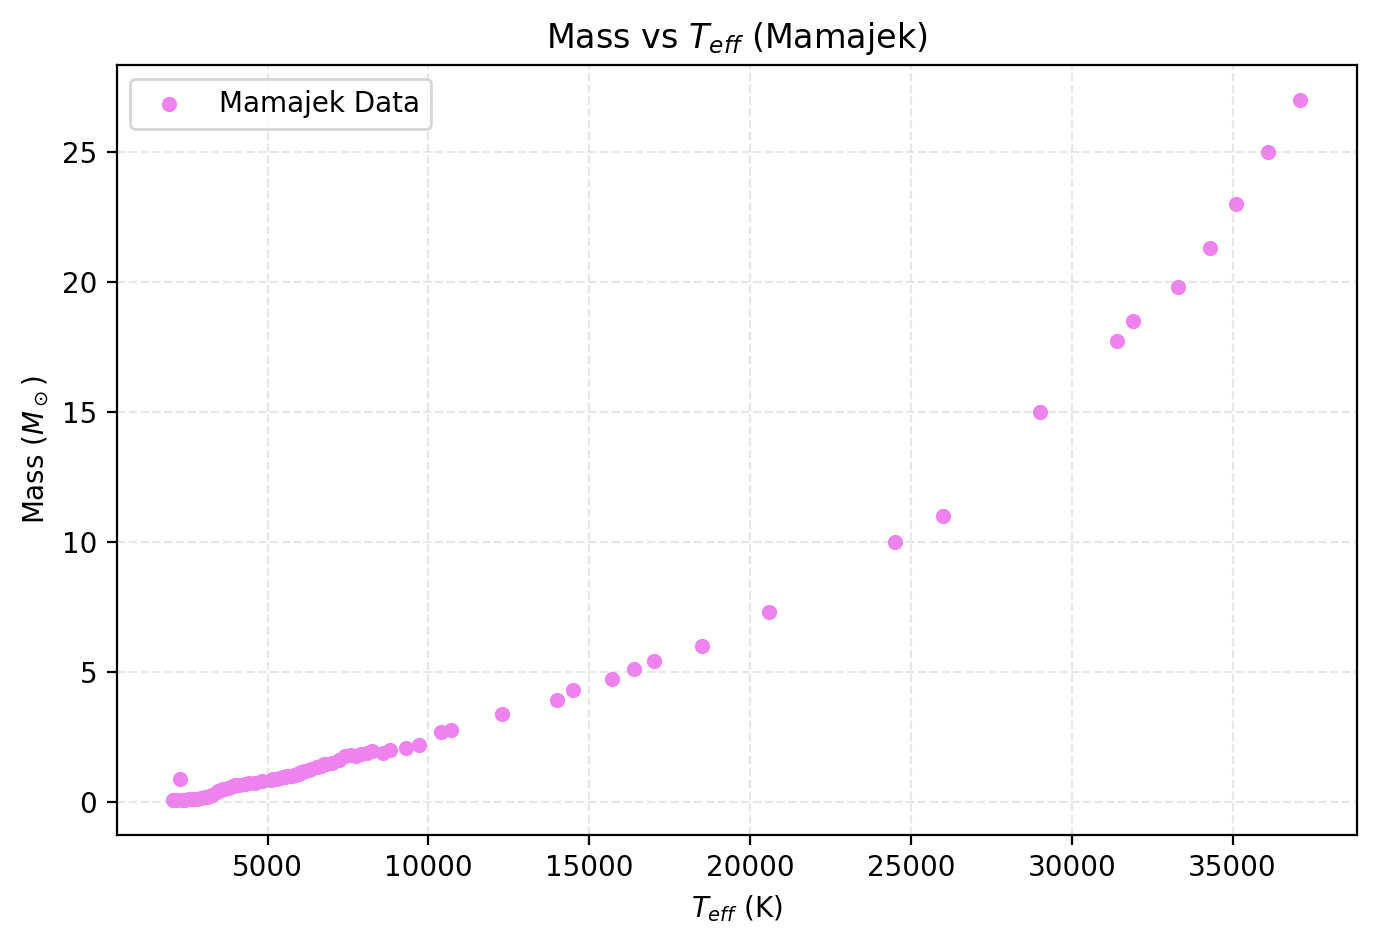

In [294]:
# Mass vs Effective temperature
fig = plt.figure(figsize=(8, 5), dpi = 200)
plt.scatter(teff, mass, s=20, c='violet', label = 'Mamajek Data')
plt.xlabel('$T_{eff}$ (K)'); plt.ylabel('Mass ($M_\odot$)')
plt.title('Mass vs $T_{eff}$ (Mamajek)'); plt.legend()
plt.grid(ls='--', alpha=0.3); plt.show()


In [ ]:
valid = np.isfinite(teff) & np.isfinite(mass) # clean the data (remove NaNs)

# Sorting data as it is necessary for the interpolation 
sorti = np.argsort(teff[valid])
teff = teff[valid][sorti]
mass_sort = mass[valid][sorti]

f = interp1d(teff, mass_sort, kind='cubic', bounds_error=True) # interpolation of the data using scipy
teff_mass = f(teff_gcns)

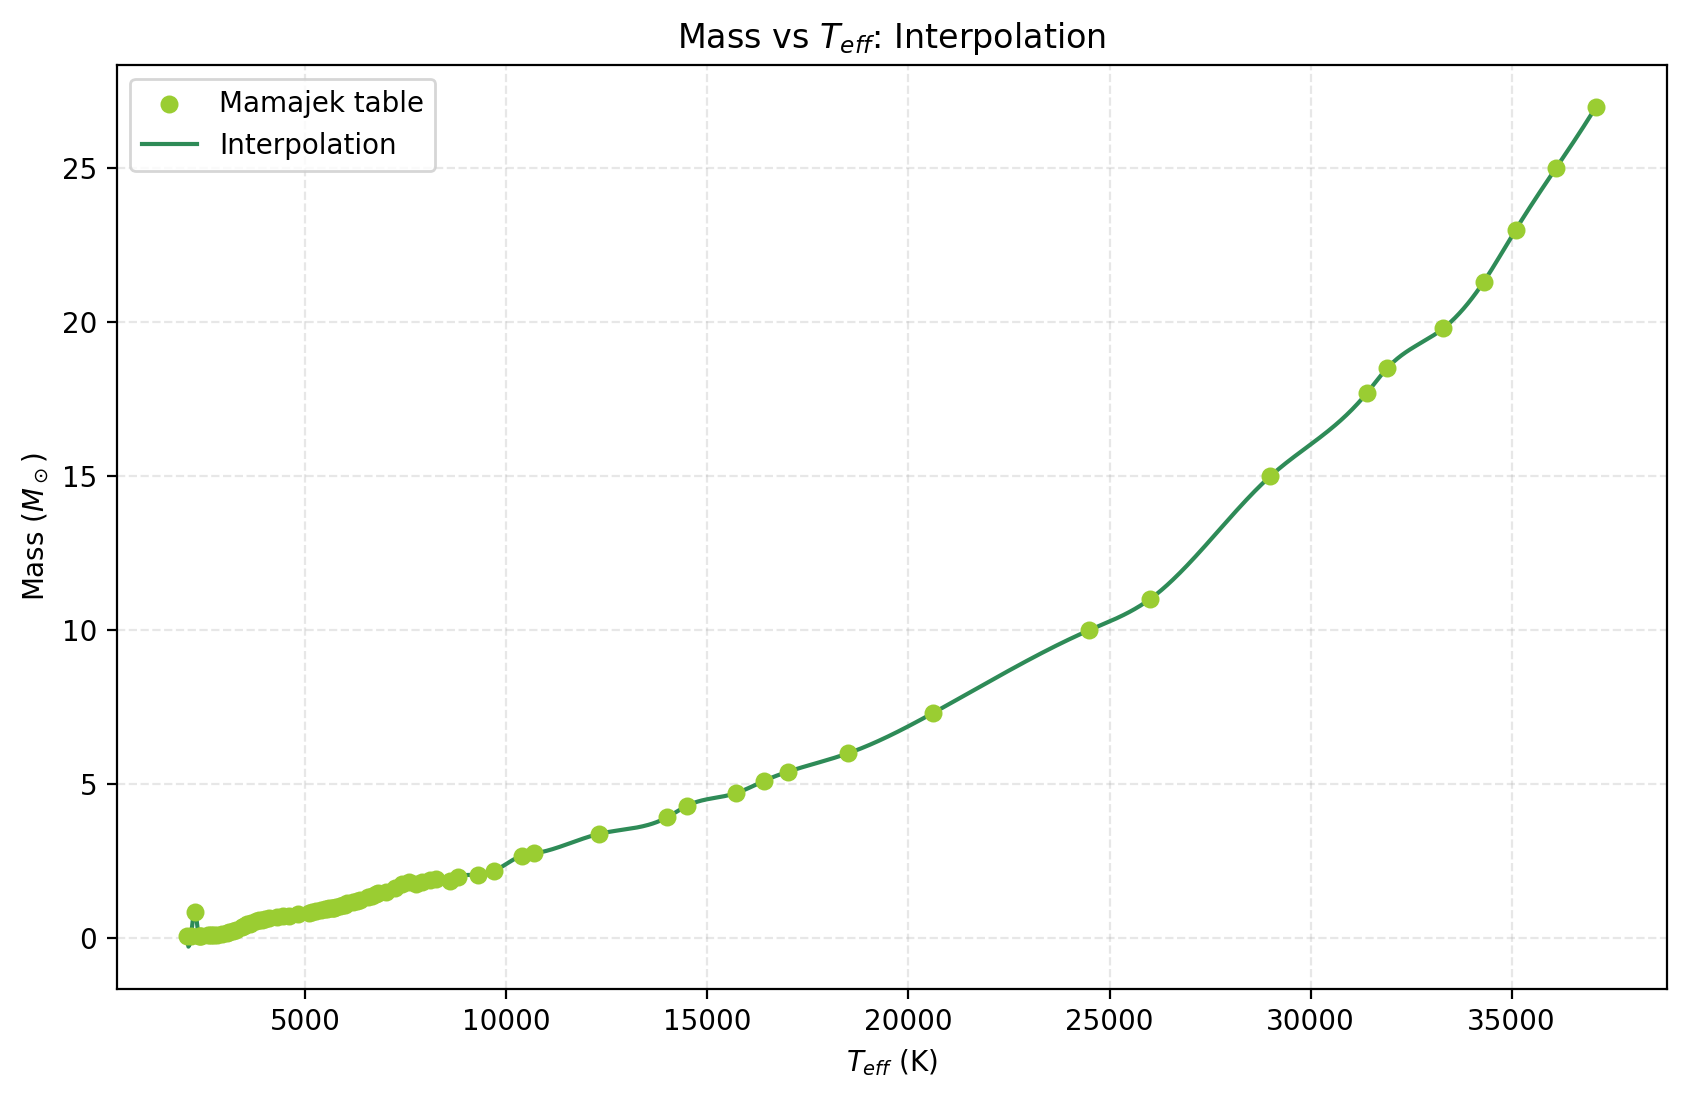

In [296]:
teff_range = np.linspace(np.nanmin(teff), np.nanmax(teff), 1000) # new teff range to get smoother curve

# Plotting the data and interpolation
fig = plt.subplots(figsize=(10, 6), dpi=200)
plt.scatter(teff, mass_sort, c='yellowgreen', s=30, zorder=3, label='Mamajek table')
plt.plot(teff_range, f(teff_range), c='seagreen', lw=1.5, label='Interpolation')
plt.xlabel('$T_{eff}$ (K)')
plt.ylabel('Mass ($M_\\odot$)')
plt.title('Mass vs $T_{eff}$: Interpolation')
plt.grid(ls='--', alpha=0.3); plt.legend(); plt.show()

In [297]:
teff_gcns = data['teff_gspphot'] # measured teff
print(f'Number of stars without an estimated T_eff: {np.count_nonzero(np.isnan(teff_gcns))}') # print missing T_eff

Number of stars without an estimated T_eff: 73613


In [298]:
# Sort data for interpolation
sort_i = np.argsort(bp_rp)
bprp_sort = bp_rp[sort_i]
mass_bp = mass[sort_i]

# Perfprm interpolation on bp-rp
f_bp = interp1d(bprp_sort, mass_bp, bounds_error=False, fill_value='extrapolate')  
bp_mass = f_bp(bprp_gcns)


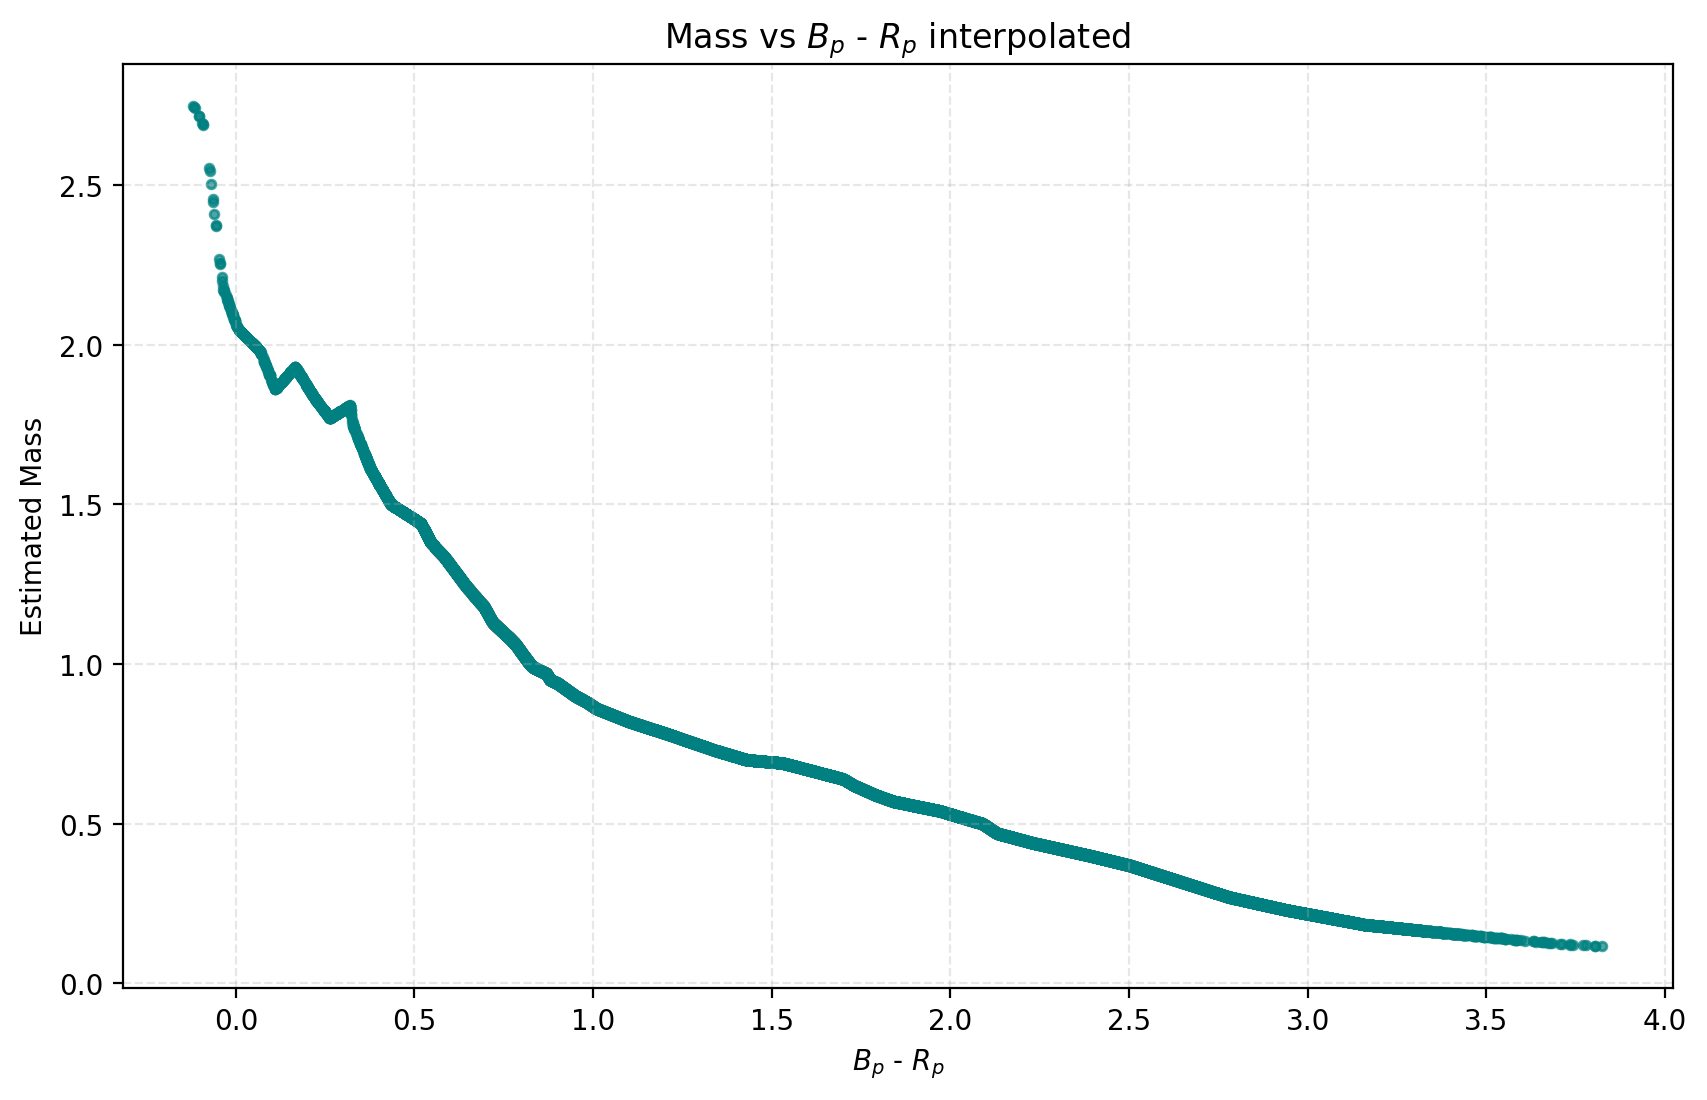

In [299]:
# Plotting
fig = plt.figure(figsize= (10, 6), dpi = 200)
plt.scatter(bprp_gcns, bp_mass, c = 'teal', label = 'Interpolation', s = 10, alpha=0.7)
plt.title('Mass vs $B_p$ - $R_p$ interpolated')
plt.xlabel('$B_p$ - $R_p$')
plt.ylabel('Estimated Mass')
plt.grid(ls = '--', alpha = 0.3)
plt.show()

In [ ]:
# Calulating missing teff
missing_teff = np.sum(np.isnan(data['teff_gspphot']))
print("Number of stars without an estimated Teff:", missing_teff)

Number of stars without an estimated Teff: 73613


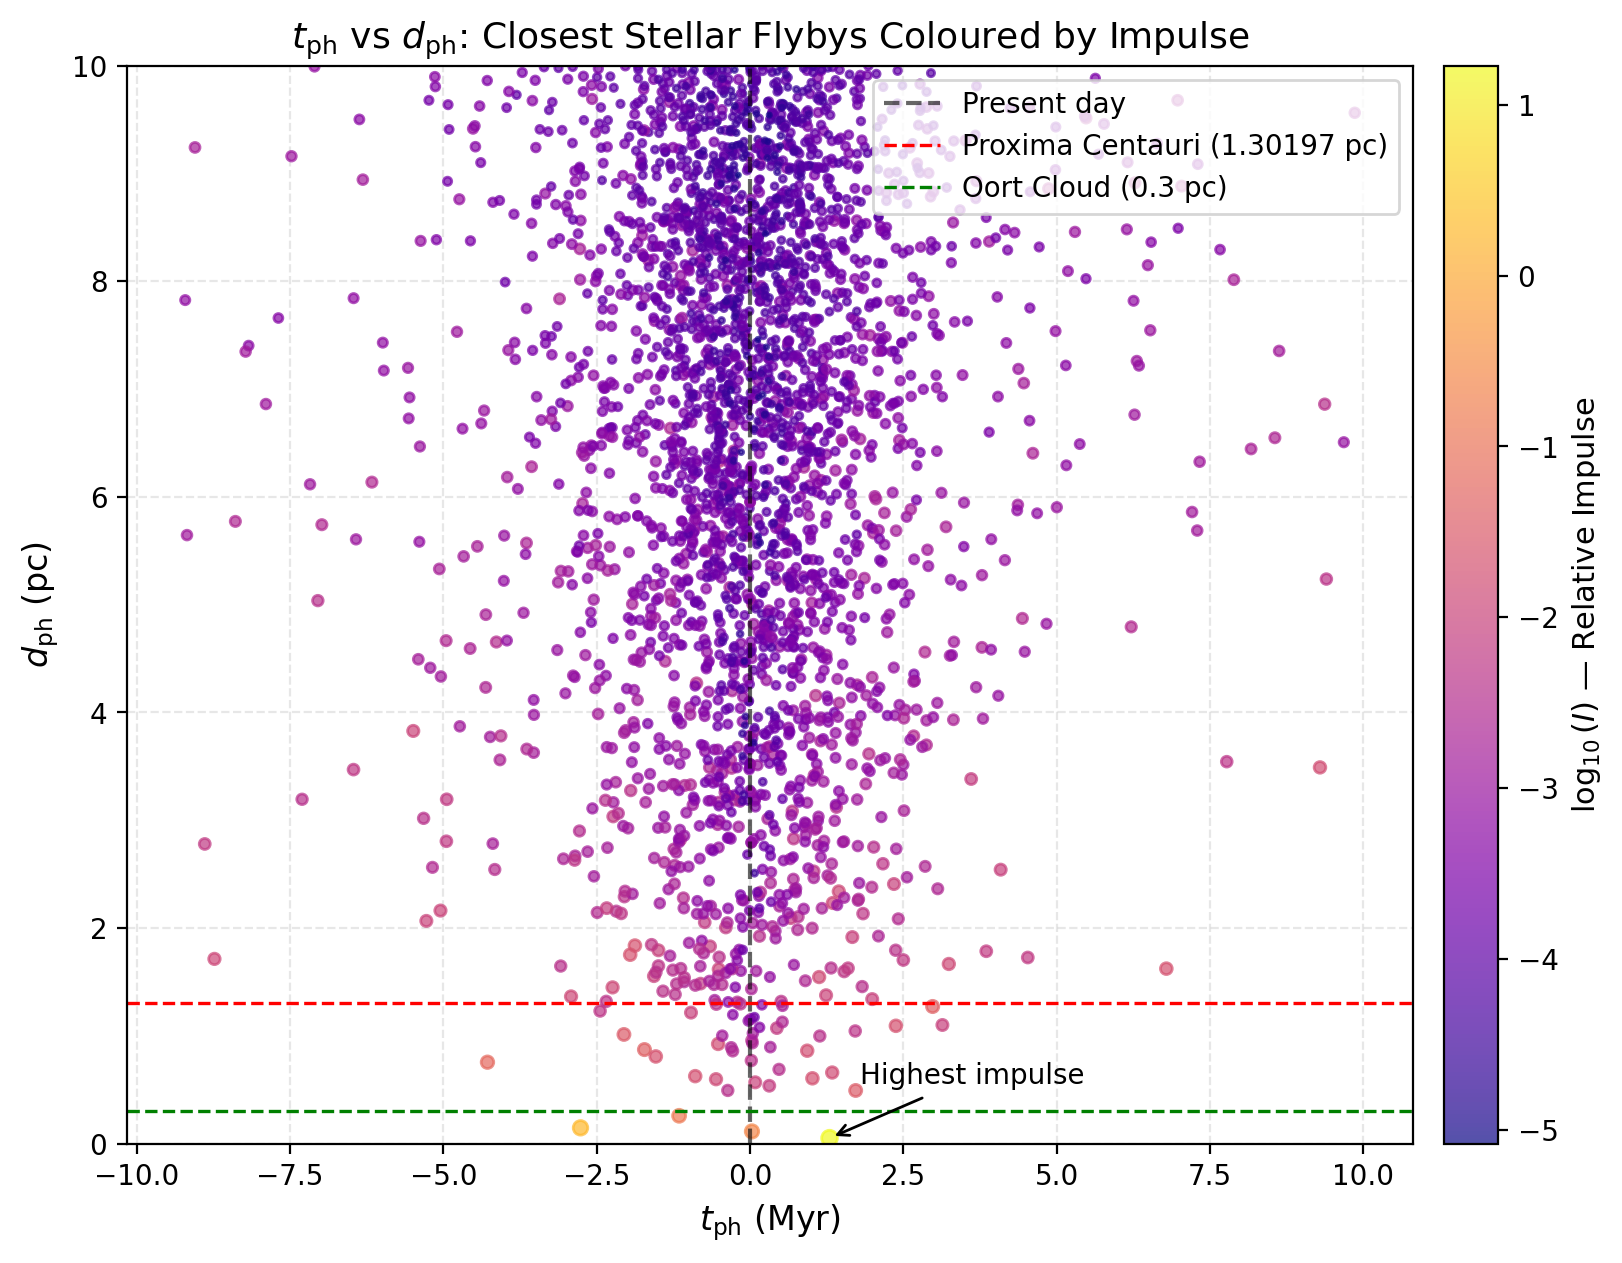


Top 5 highest impulse flybys:
1. tph = 1.294 Myr | dph = 0.0513 pc | log10(I) = 1.229
2. tph = -2.766 Myr | dph = 0.1466 pc | log10(I) = 0.246
3. tph = 0.029 Myr | dph = 0.1135 pc | log10(I) = -0.606
4. tph = -1.158 Myr | dph = 0.2584 pc | log10(I) = -0.884
5. tph = -4.283 Myr | dph = 0.7555 pc | log10(I) = -1.206


In [ ]:
# I was experiencing a lot of bugs in this piece of my code, hence it has been fixed by AI (Claude.ai)
## mass estimation and masking data
teff_m = data['teff_gspphot'][mask]                                   
bprp_m = (data['PHOT_BP_MEAN_MAG_1'] - data['PHOT_RP_MEAN_MAG_1'])[mask]  

mass_gaia = np.full(len(dph), np.nan)

# Step 1: use teff where available
has_teff = np.isfinite(teff_m)
mass_gaia[has_teff] = f(np.clip(teff_m[has_teff], teff.min(), teff.max()))

# Step 2: use bp-rp colour for the rest
no_teff = ~has_teff & np.isfinite(bprp_m)
mass_gaia[no_teff] = f_bp(bprp_m[no_teff])


# Impulse 
impulse = mass_gaia / (v * dph**2)
impulse_log = np.log10(np.abs(impulse))

#  Plot mask
plot_mask = ((dph < 10) & (np.abs(tph) < 10e6) & np.isfinite(impulse_log) & (dph > 0))

tph_plot = tph[plot_mask]
dph_plot = dph[plot_mask]
impulse_plot = impulse_log[plot_mask]

# Plot 
size_scaled = 2 + 30 * (impulse_plot - impulse_plot.min()) / (impulse_plot.max() - impulse_plot.min())

# Set up digure size
fig, ax = plt.subplots(figsize=(10, 7), dpi=200)
sc = ax.scatter(tph_plot / 1e6, dph_plot, c=impulse_plot, s=size_scaled, cmap='plasma', alpha=0.7, zorder=2)

cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label(r'$\log_{10}(I)$ — Relative Impulse', fontsize=11)

ax.axvline(0, c='k', ls='--', alpha=0.6, label='Present day')
ax.axhline(proxima_centauri, c='r', ls='--', lw=1.2, label=f'Proxima Centauri ({proxima_centauri} pc)')
ax.axhline(oort_cloud, c='g', ls='--', lw=1.2, label=f'Oort Cloud ({oort_cloud} pc)')

imax = np.argmax(impulse_plot)
ax.annotate('Highest impulse', xy=(tph_plot[imax] / 1e6, dph_plot[imax]), xytext=(tph_plot[imax] / 1e6 + 0.5, dph_plot[imax] + 0.5), arrowprops=dict(arrowstyle='->',color='black'), color='black')
ax.set_xlabel(r'$t_{\rm ph}$ (Myr)', fontsize=12)
ax.set_ylabel(r'$d_{\rm ph}$ (pc)', fontsize=12)
ax.set_title(r'$t_{\rm ph}$ vs $d_{\rm ph}$: Closest Stellar Flybys Coloured by Impulse', fontsize=13)
ax.set_ylim(0, 10)
ax.grid(ls='--', alpha=0.3)
ax.legend(loc = 'upper right')
plt.show()

# Top 5 
print("\nTop 5 highest impulse flybys:")
top5 = np.argsort(impulse_plot)[-5:][::-1]
for i, idx in enumerate(top5):
    print(f"{i+1}. tph = {tph_plot[idx]/1e6:.3f} Myr | dph = {dph_plot[idx]:.4f} pc | log10(I) = {impulse_plot[idx]:.3f}")

### Part 3


In [ ]:
# Read in Ultracool sheet into my sata
ultracool = r"Ultracool.csv"
df = pd.read_csv(ultracool)

# Unpacking the required values

J = df['J_MKO'].values
Jerr = df['Jerr_MKO'].values
Ks = df['K_MKO'].values
Kserr = df['Kerr_MKO'].values
spt = df['sptnum_formula'].values
plx = df['plx_formula'].values
plxerr = df['plxerr_formula'].values
pmrau = df['pmra_formula'].values
pmrauerr= df['pmraerr_formula'].values
pmdecu = df['pmdec_formula'].values
pmdecuerr = df['pmdecerr_formula'].values
vru = df['rv_formula'].values
vruerr = df['rverr_formula'].values

print(len(spt))

3890


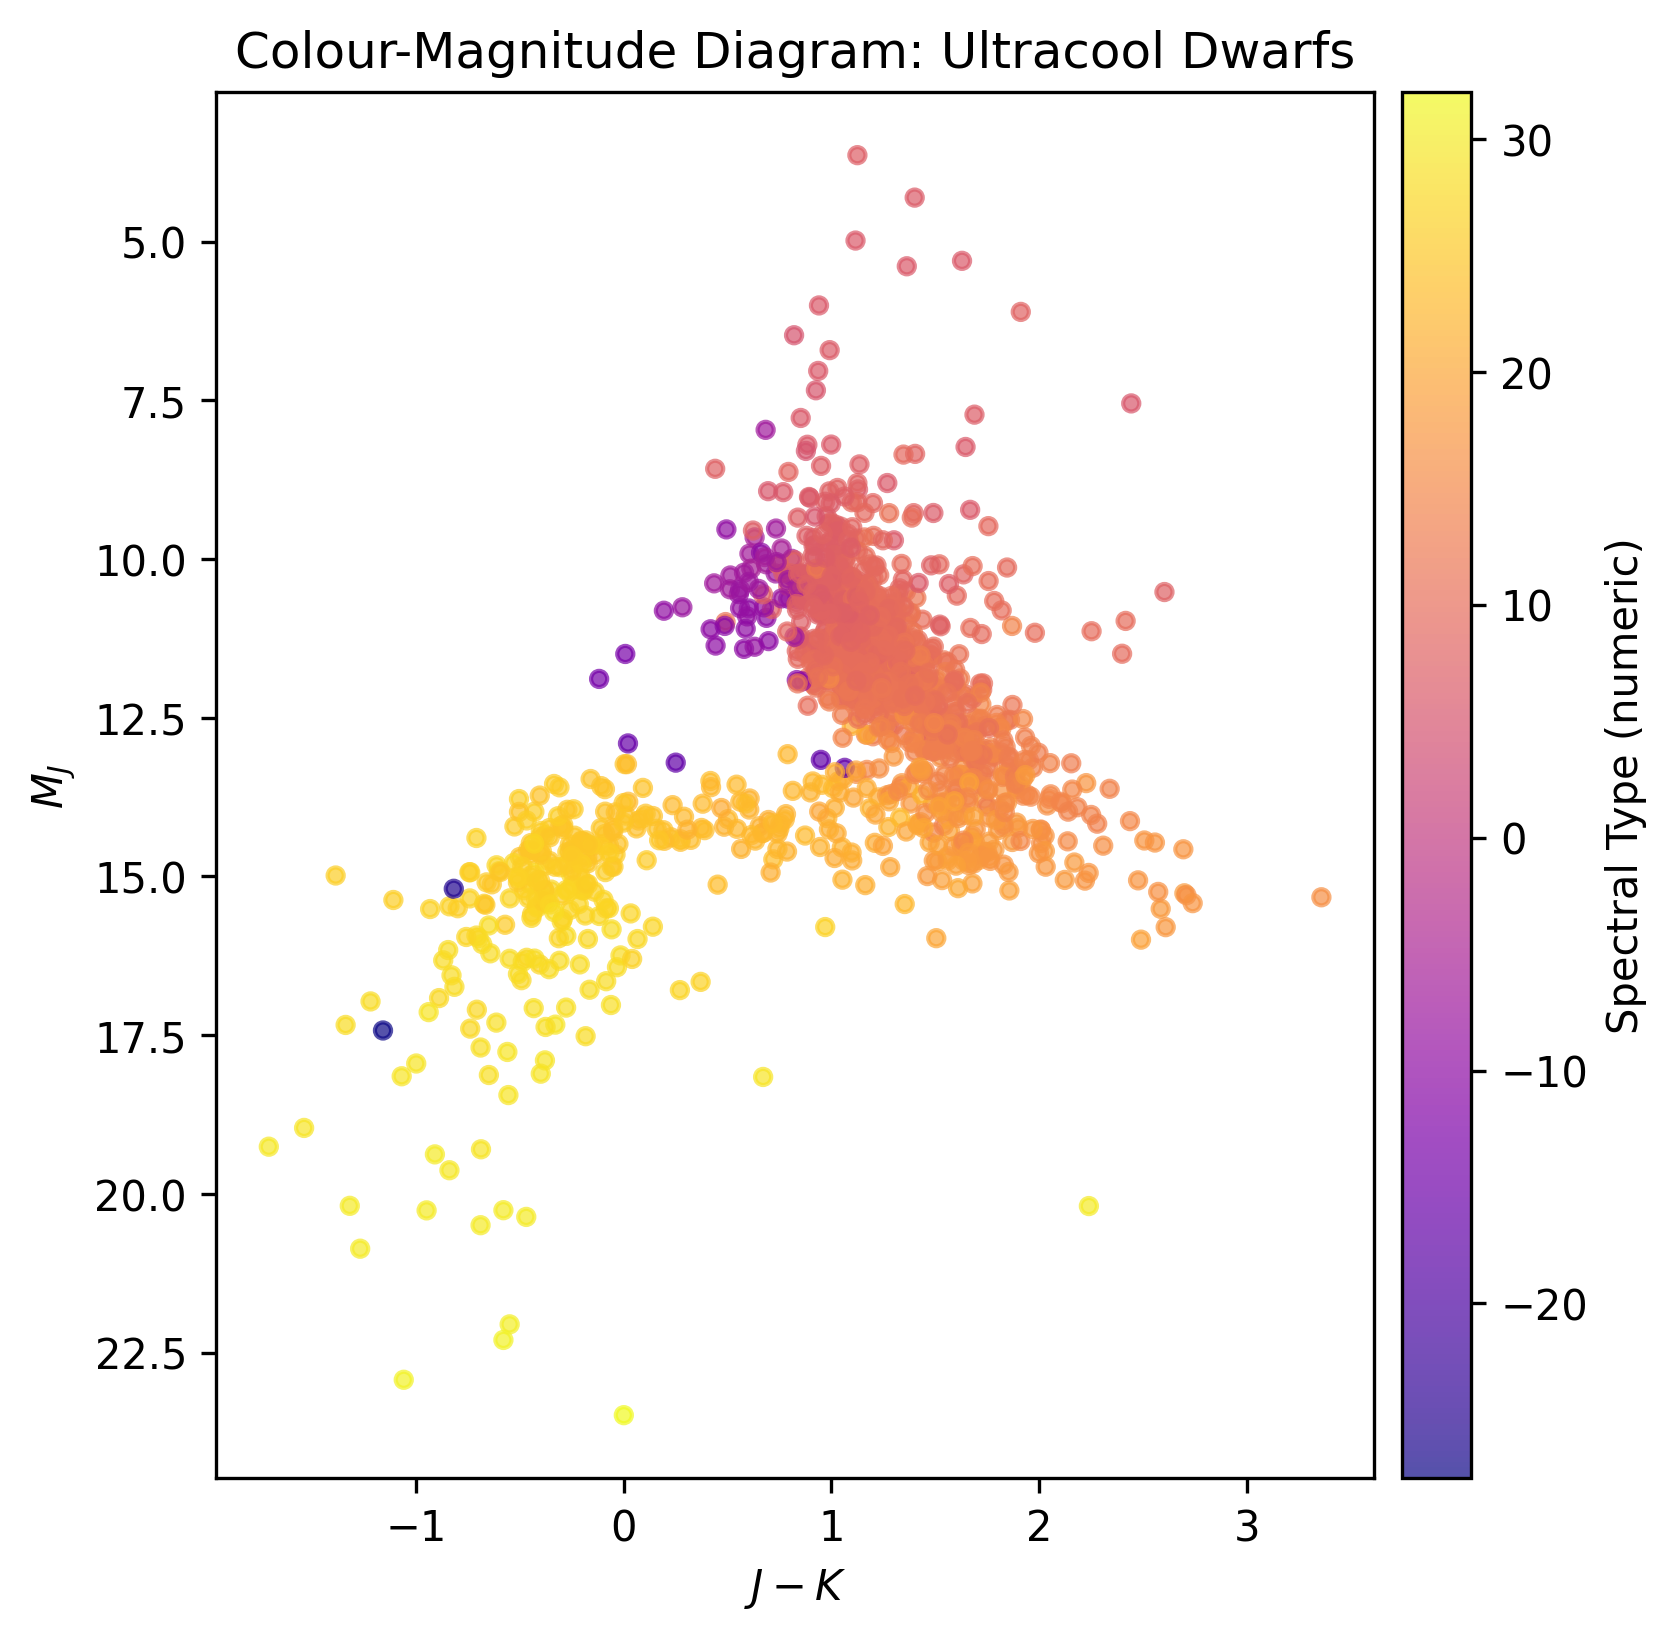

In [ ]:
# Making colour magnitude diagram
d = 1000 / plx # distance in pc: d = 1000/parallax (parallax in mas)
absJ = J - 5 * np.log10(d) + 5 # absolute magnitude formula
JKs = J - Ks # J-K formula

# Plotting
fig, ax = plt.subplots(figsize=(6, 6), dpi = 300)
sc = ax.scatter(JKs, absJ, c=spt, cmap='plasma', s=15, alpha=0.7)
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('Spectral Type (numeric)')
ax.invert_yaxis()
plt.xlabel(r'$J - K$')
plt.ylabel(r'$M_J$')
plt.title('Colour-Magnitude Diagram: Ultracool Dwarfs'); plt.show()

In [305]:
print(f"Number of sources with measured RVs: {len(vru)}")

Number of sources with measured RVs: 3890


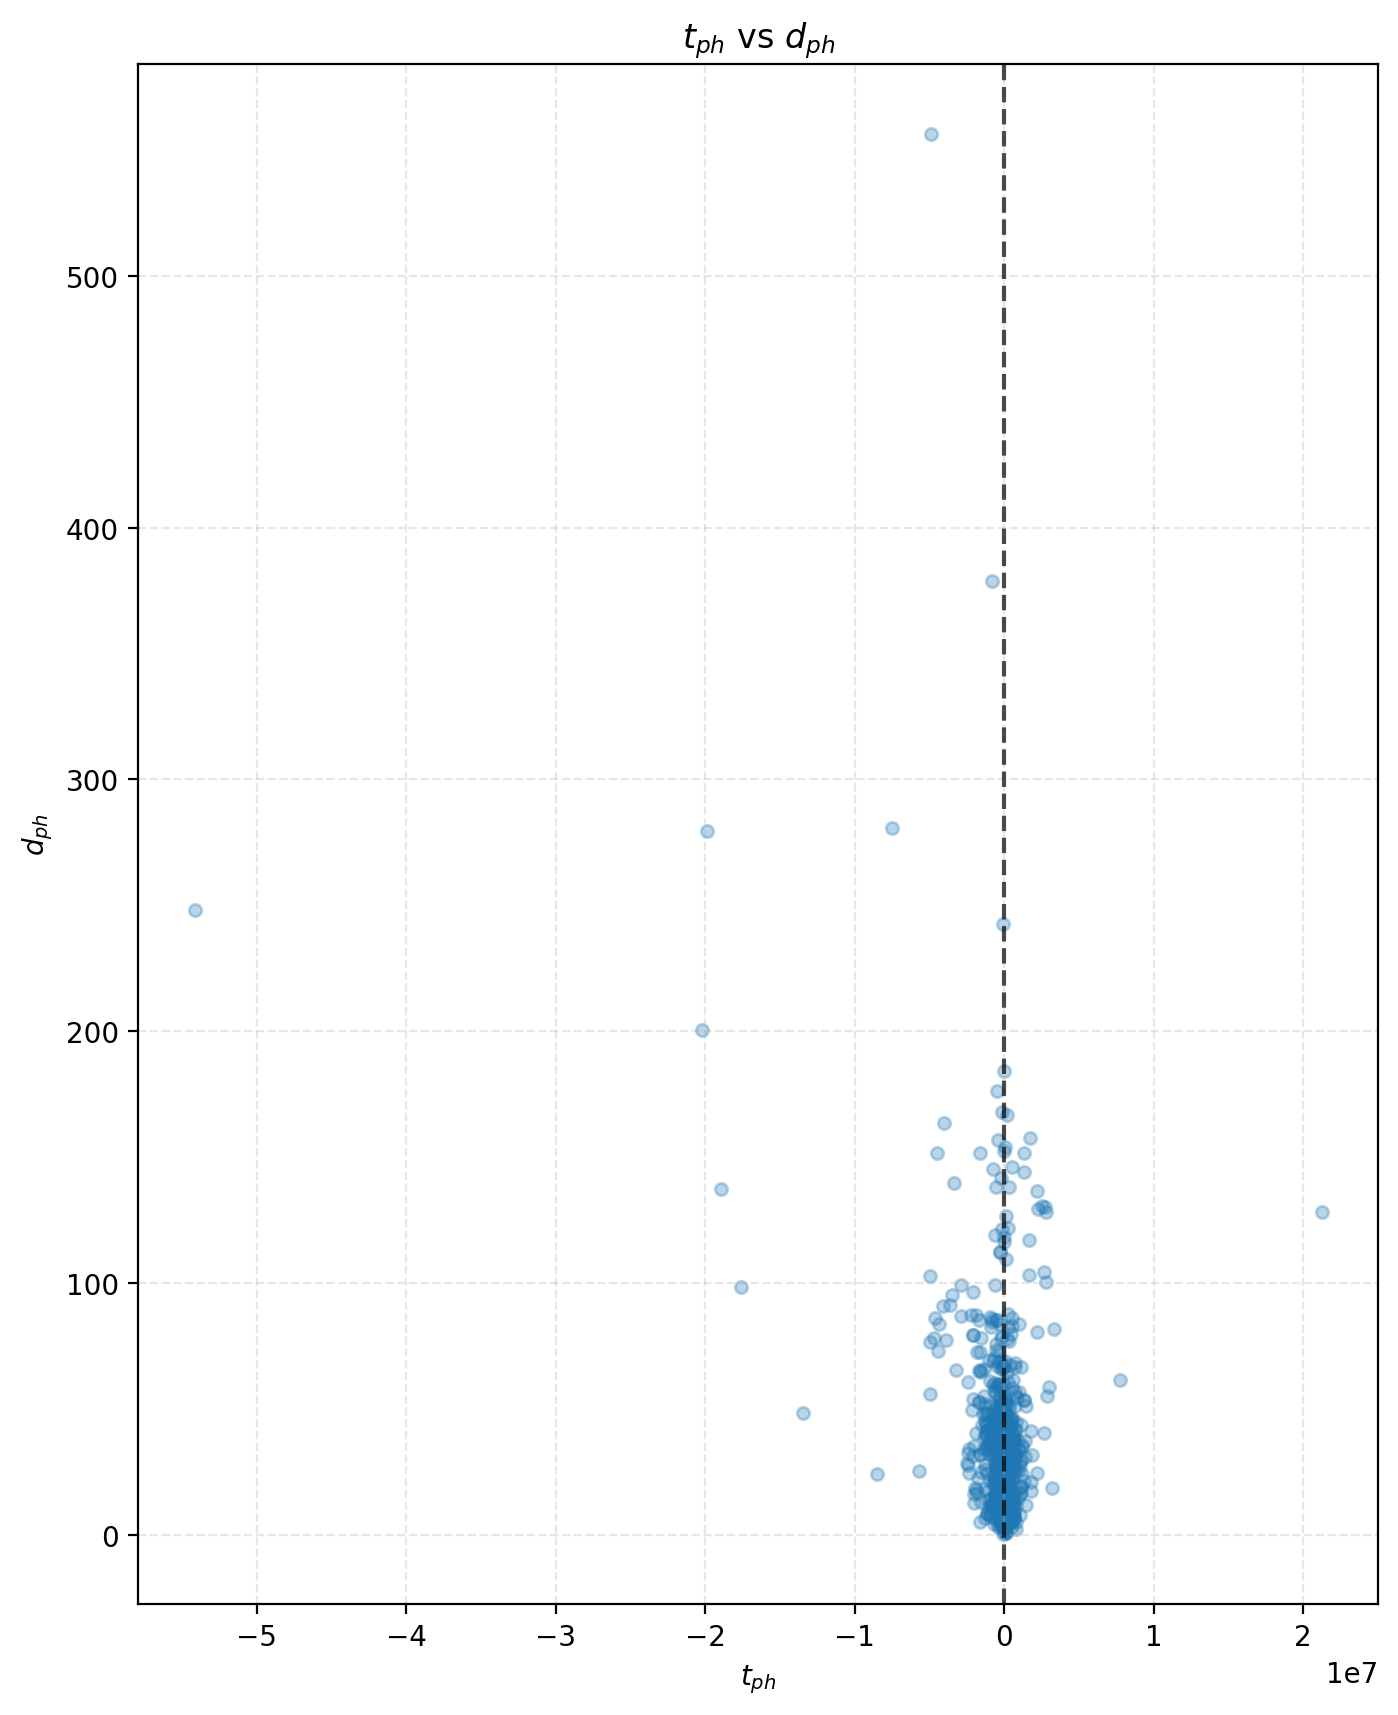

In [306]:
# Finding the time and distance at perihelion
c1 = 0.97779e9 # constant 1 [10^3 pc km^-1 yr^-1]
c2 = 4.74047 # constant 2 [AU km^-1 yr^-1]

vtu = c2 * (np.sqrt((pmrau**2) + (pmdecu**2))/plx) # transverse velocity (formula given in lab notes)
vu = np.sqrt(vtu**2 + vru**2) # total velocity

tphu = -c1 * (1/plx) * (vru / vu**2) # time at perihelion
dphu = (1e3) * (1/plx) *(vtu/vu) # distance at perihelion

# Plotting t_ph vs d_ph
fig = plt.figure(figsize=(8, 10), dpi = 200)
plt.scatter(tphu, dphu, s = 20, alpha = 0.3)
plt.axvline(0, c = 'k', ls = '--', alpha = 0.7)
plt.title('$t_{ph}$ vs $d_{ph}$')
plt.xlabel('$t_{ph}$'); plt.ylabel('$d_{ph}$'); plt.grid(ls = '--', alpha = 0.3)
plt.show()

In [ ]:
# Using same monte carlo function
tphu, dphu, tphu_err, dphu_err = monte_carlo_sampling(plx, plxerr, vru, vruerr, pmrau, pmrauerr, pmdecu, pmdecuerr, N=1000)

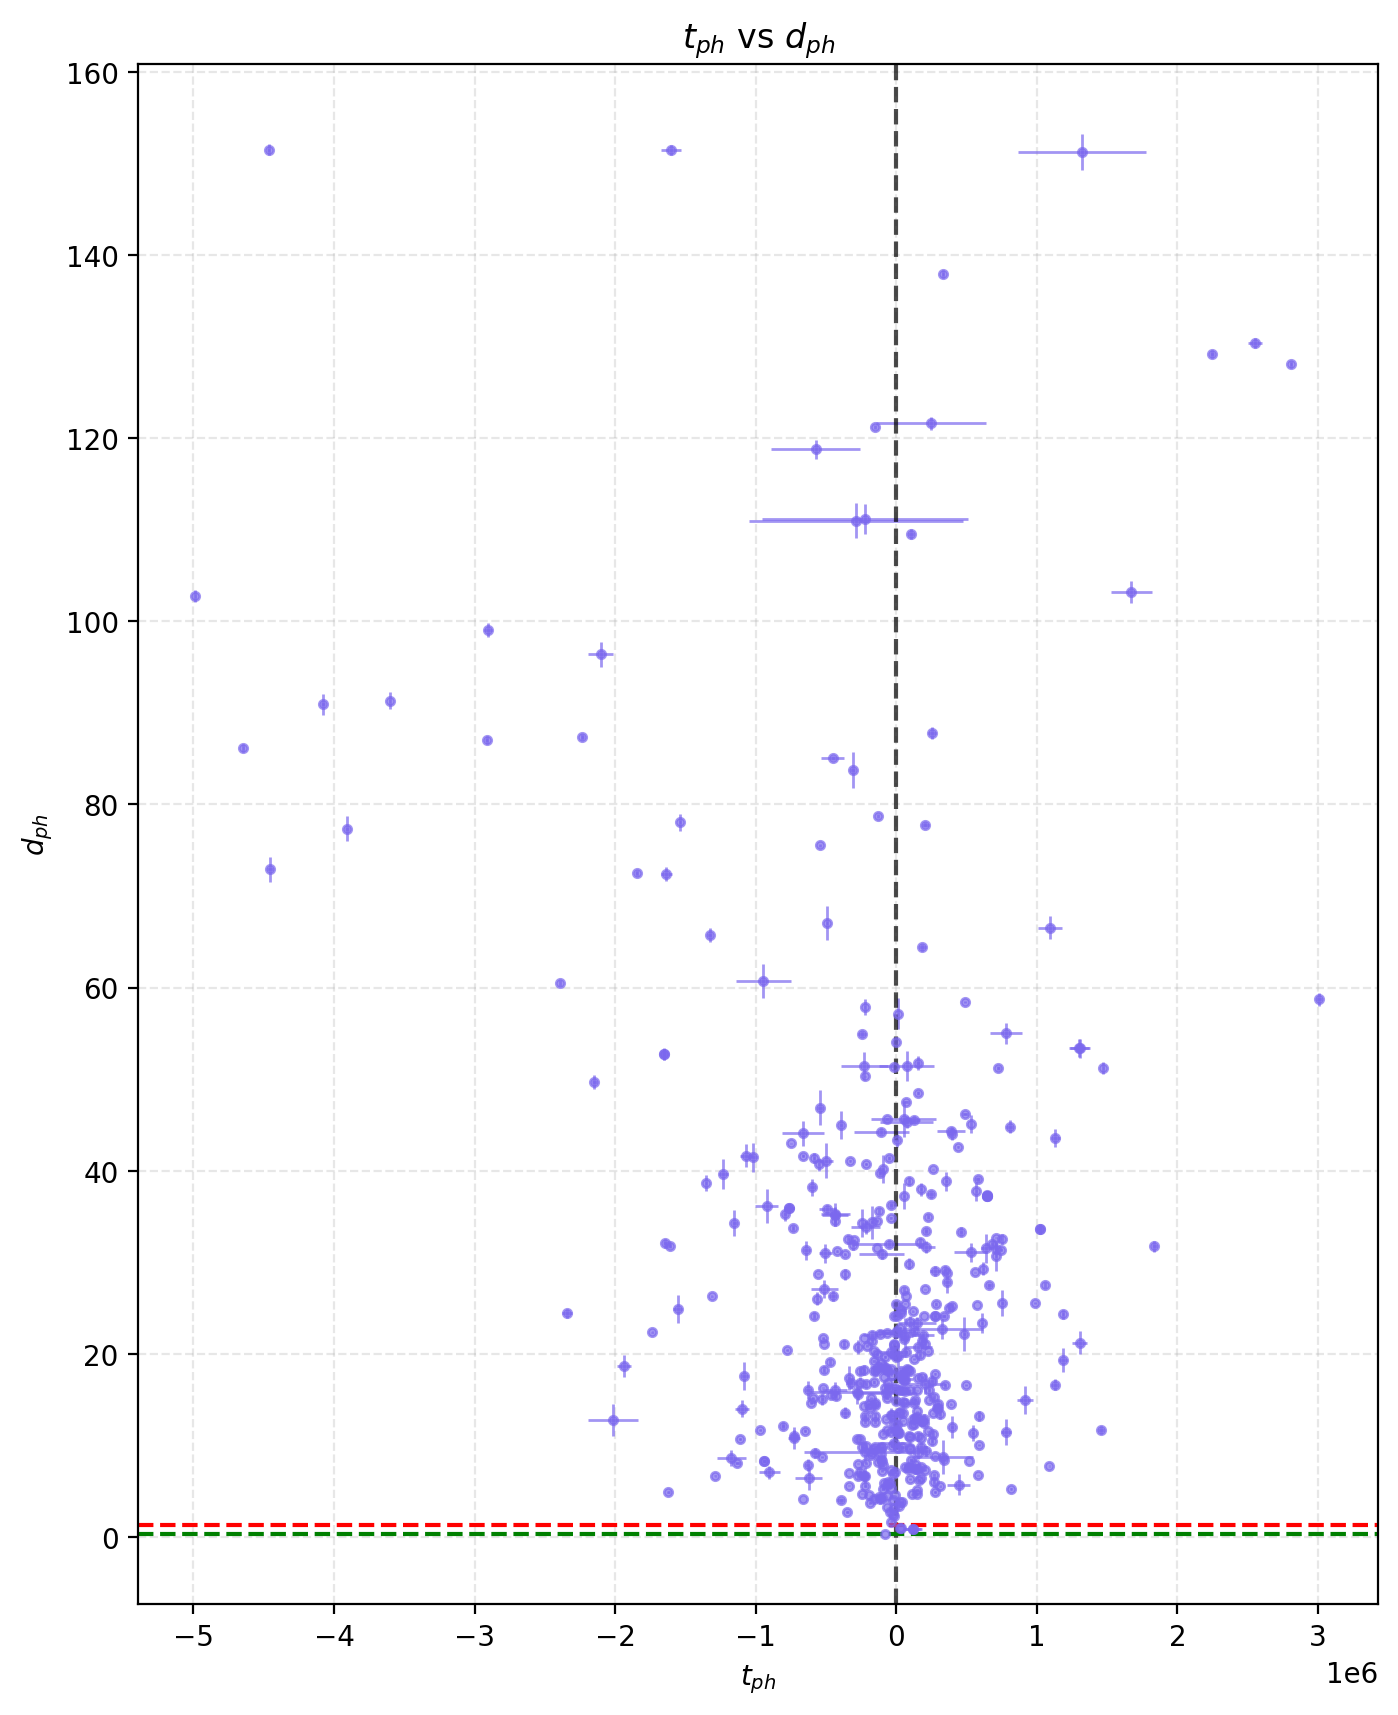

In [ ]:
# Plotting and filtering data with large error bars to disregard them
fig = plt.figure(figsize=(8, 10), dpi = 200)
large = (tphu_err < 2e7) & (dphu_err < 2)
plt.errorbar(tphu[large], dphu[large], xerr=tphu_err[large], yerr=dphu_err[large], fmt='.', color='mediumslateblue', alpha=0.7, linewidth=1)
plt.axvline(0, c = 'k', ls = '--', alpha = 0.7)
plt.title('$t_{ph}$ vs $d_{ph}$')
plt.xlabel('$t_{ph}$'); plt.ylabel('$d_{ph}$'); plt.grid(ls = '--', alpha = 0.3)
plt.axhline(proxima_centauri, c = 'r', ls = '--')
plt.axhline(oort_cloud, c = 'g', ls = '--')
plt.show()

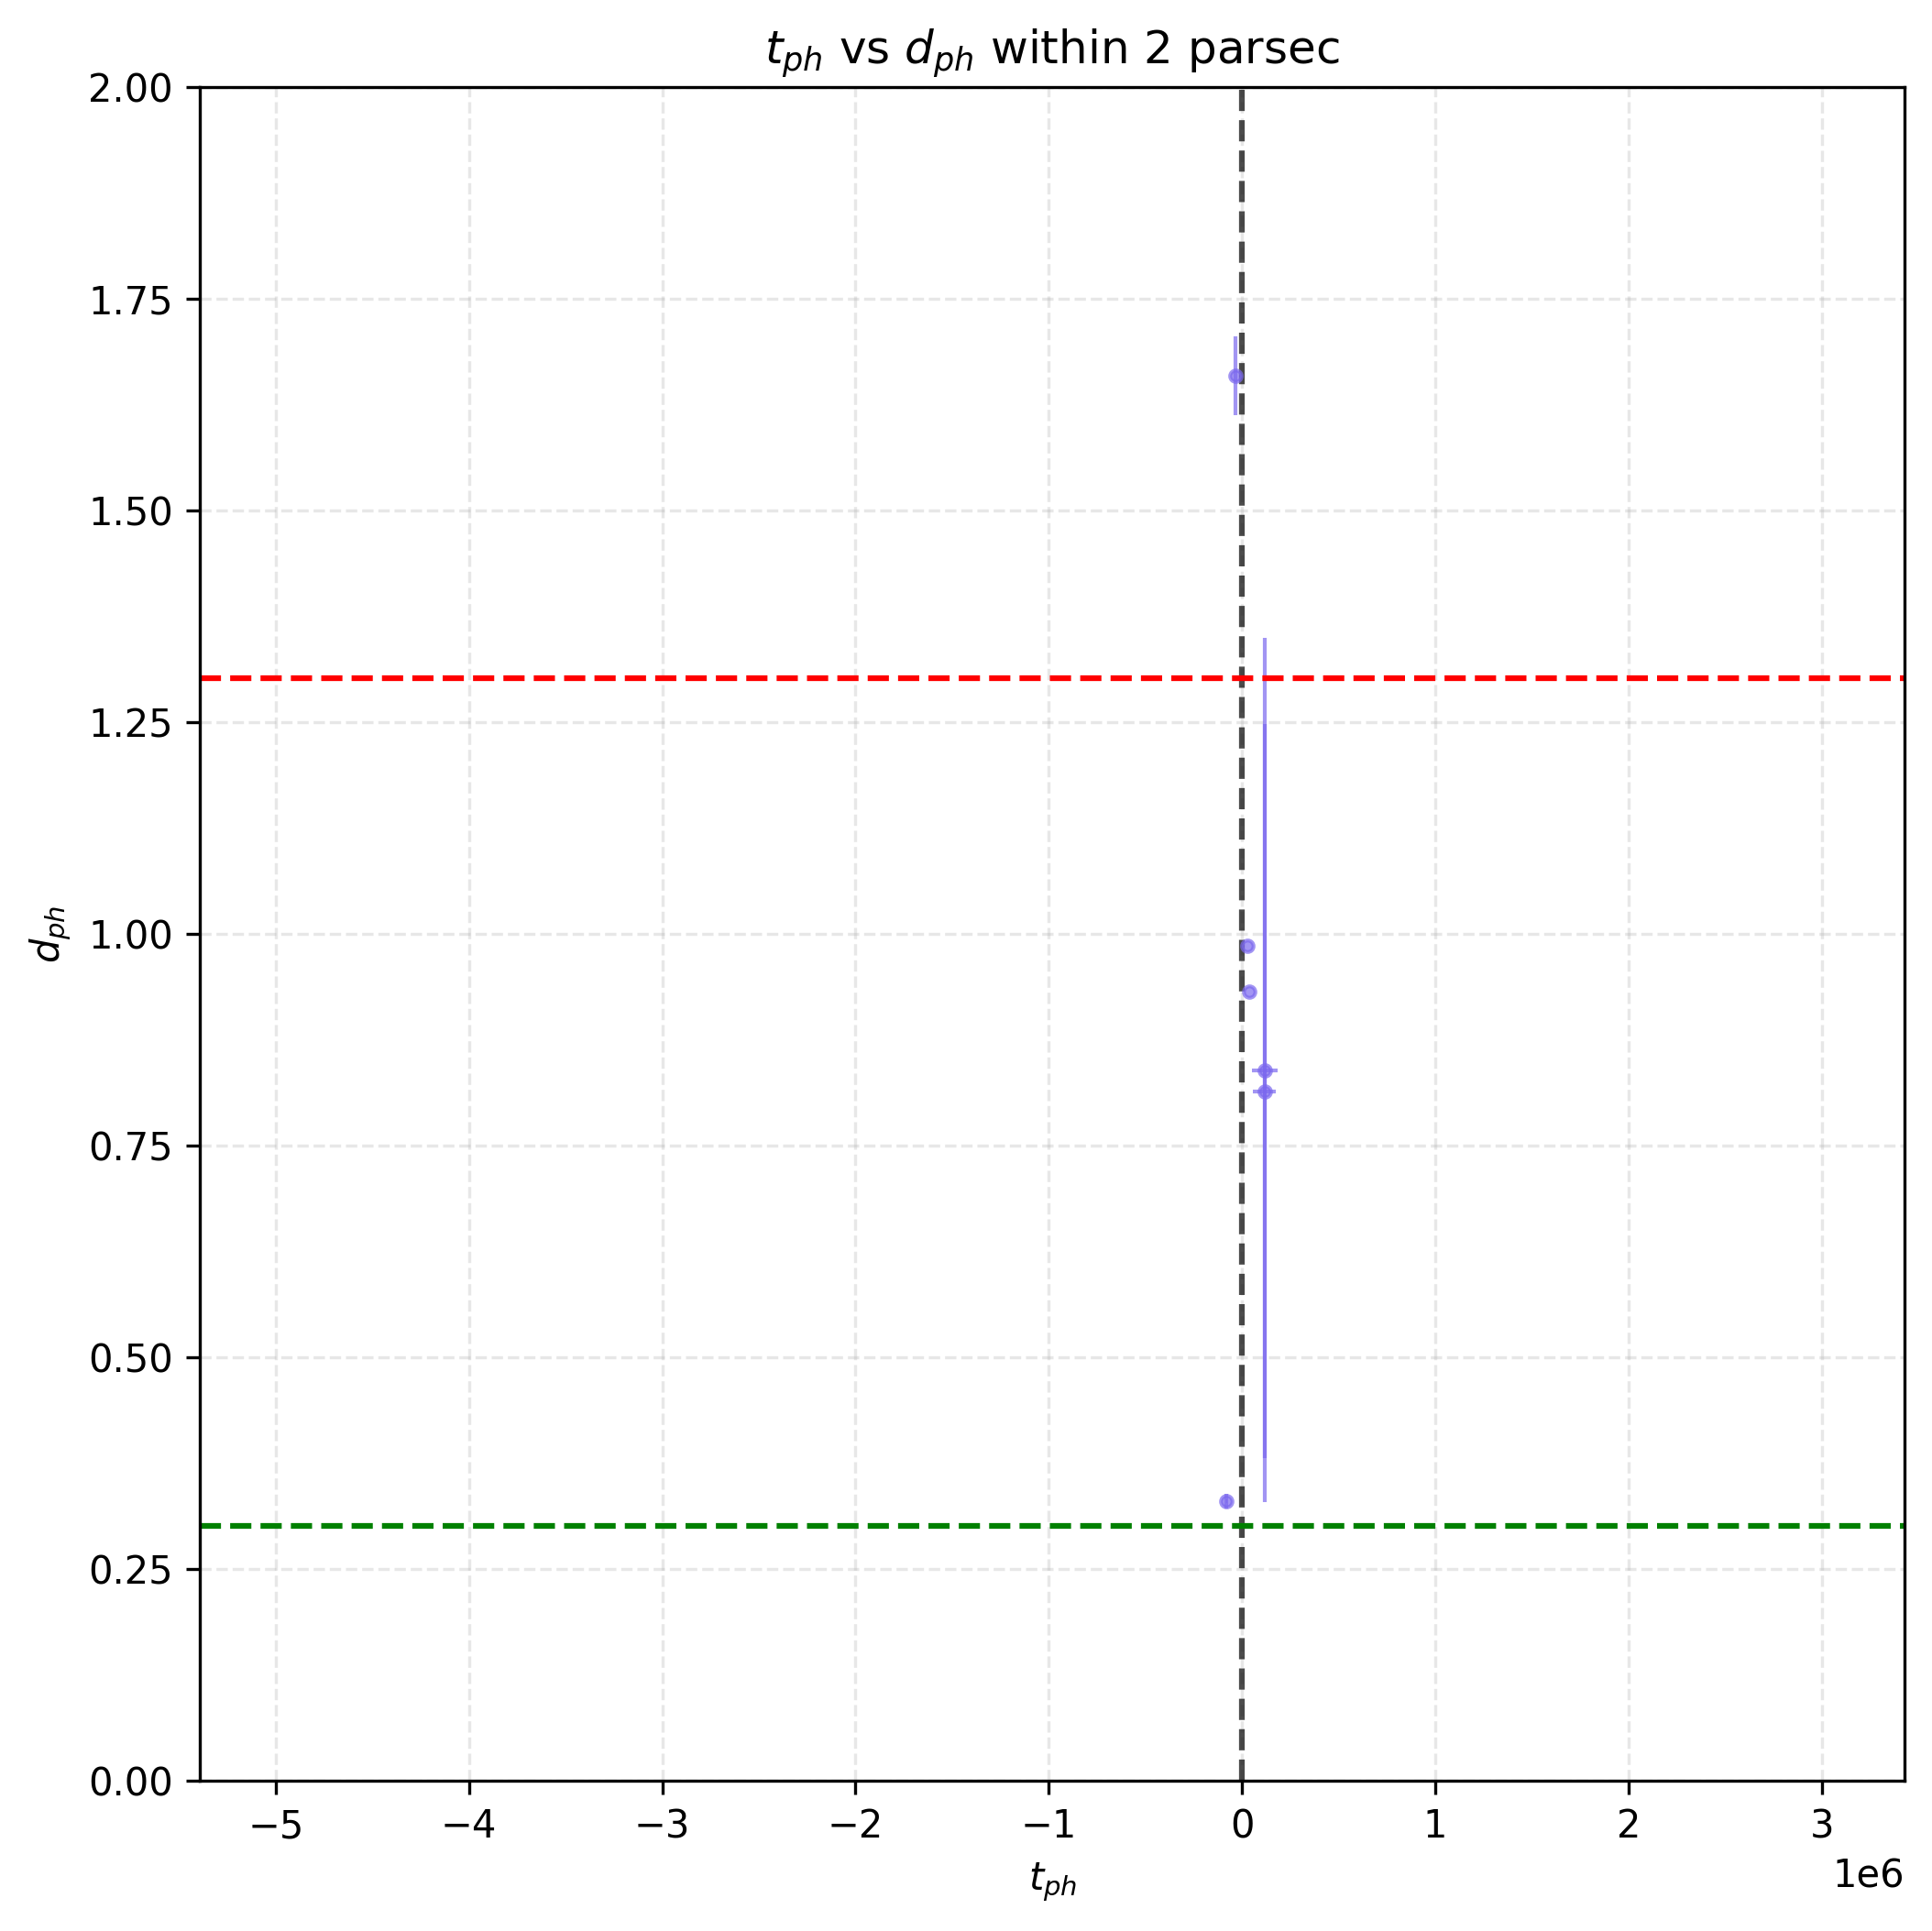

In [ ]:
# Plotting within 2 pc
fig = plt.figure(figsize=(8, 8), dpi = 300) 
large_2pc = (tphu_err < 2e7) & (dphu_err < 2)
plt.errorbar(tphu[large], dphu[large], xerr=tphu_err[large], yerr=dphu_err[large], fmt='.', color='mediumslateblue', alpha=0.7, linewidth=1)
plt.axvline(0, c = 'k', ls = '--', alpha = 0.7)
plt.title('$t_{ph}$ vs $d_{ph}$ within 2 parsec')
plt.xlabel('$t_{ph}$'); plt.ylabel('$d_{ph}$'); plt.grid(ls = '--', alpha = 0.3)
plt.axhline(proxima_centauri, c = 'r', ls = '--')
plt.axhline(oort_cloud, c = 'g', ls = '--')
plt.ylim(0,2)
plt.show()

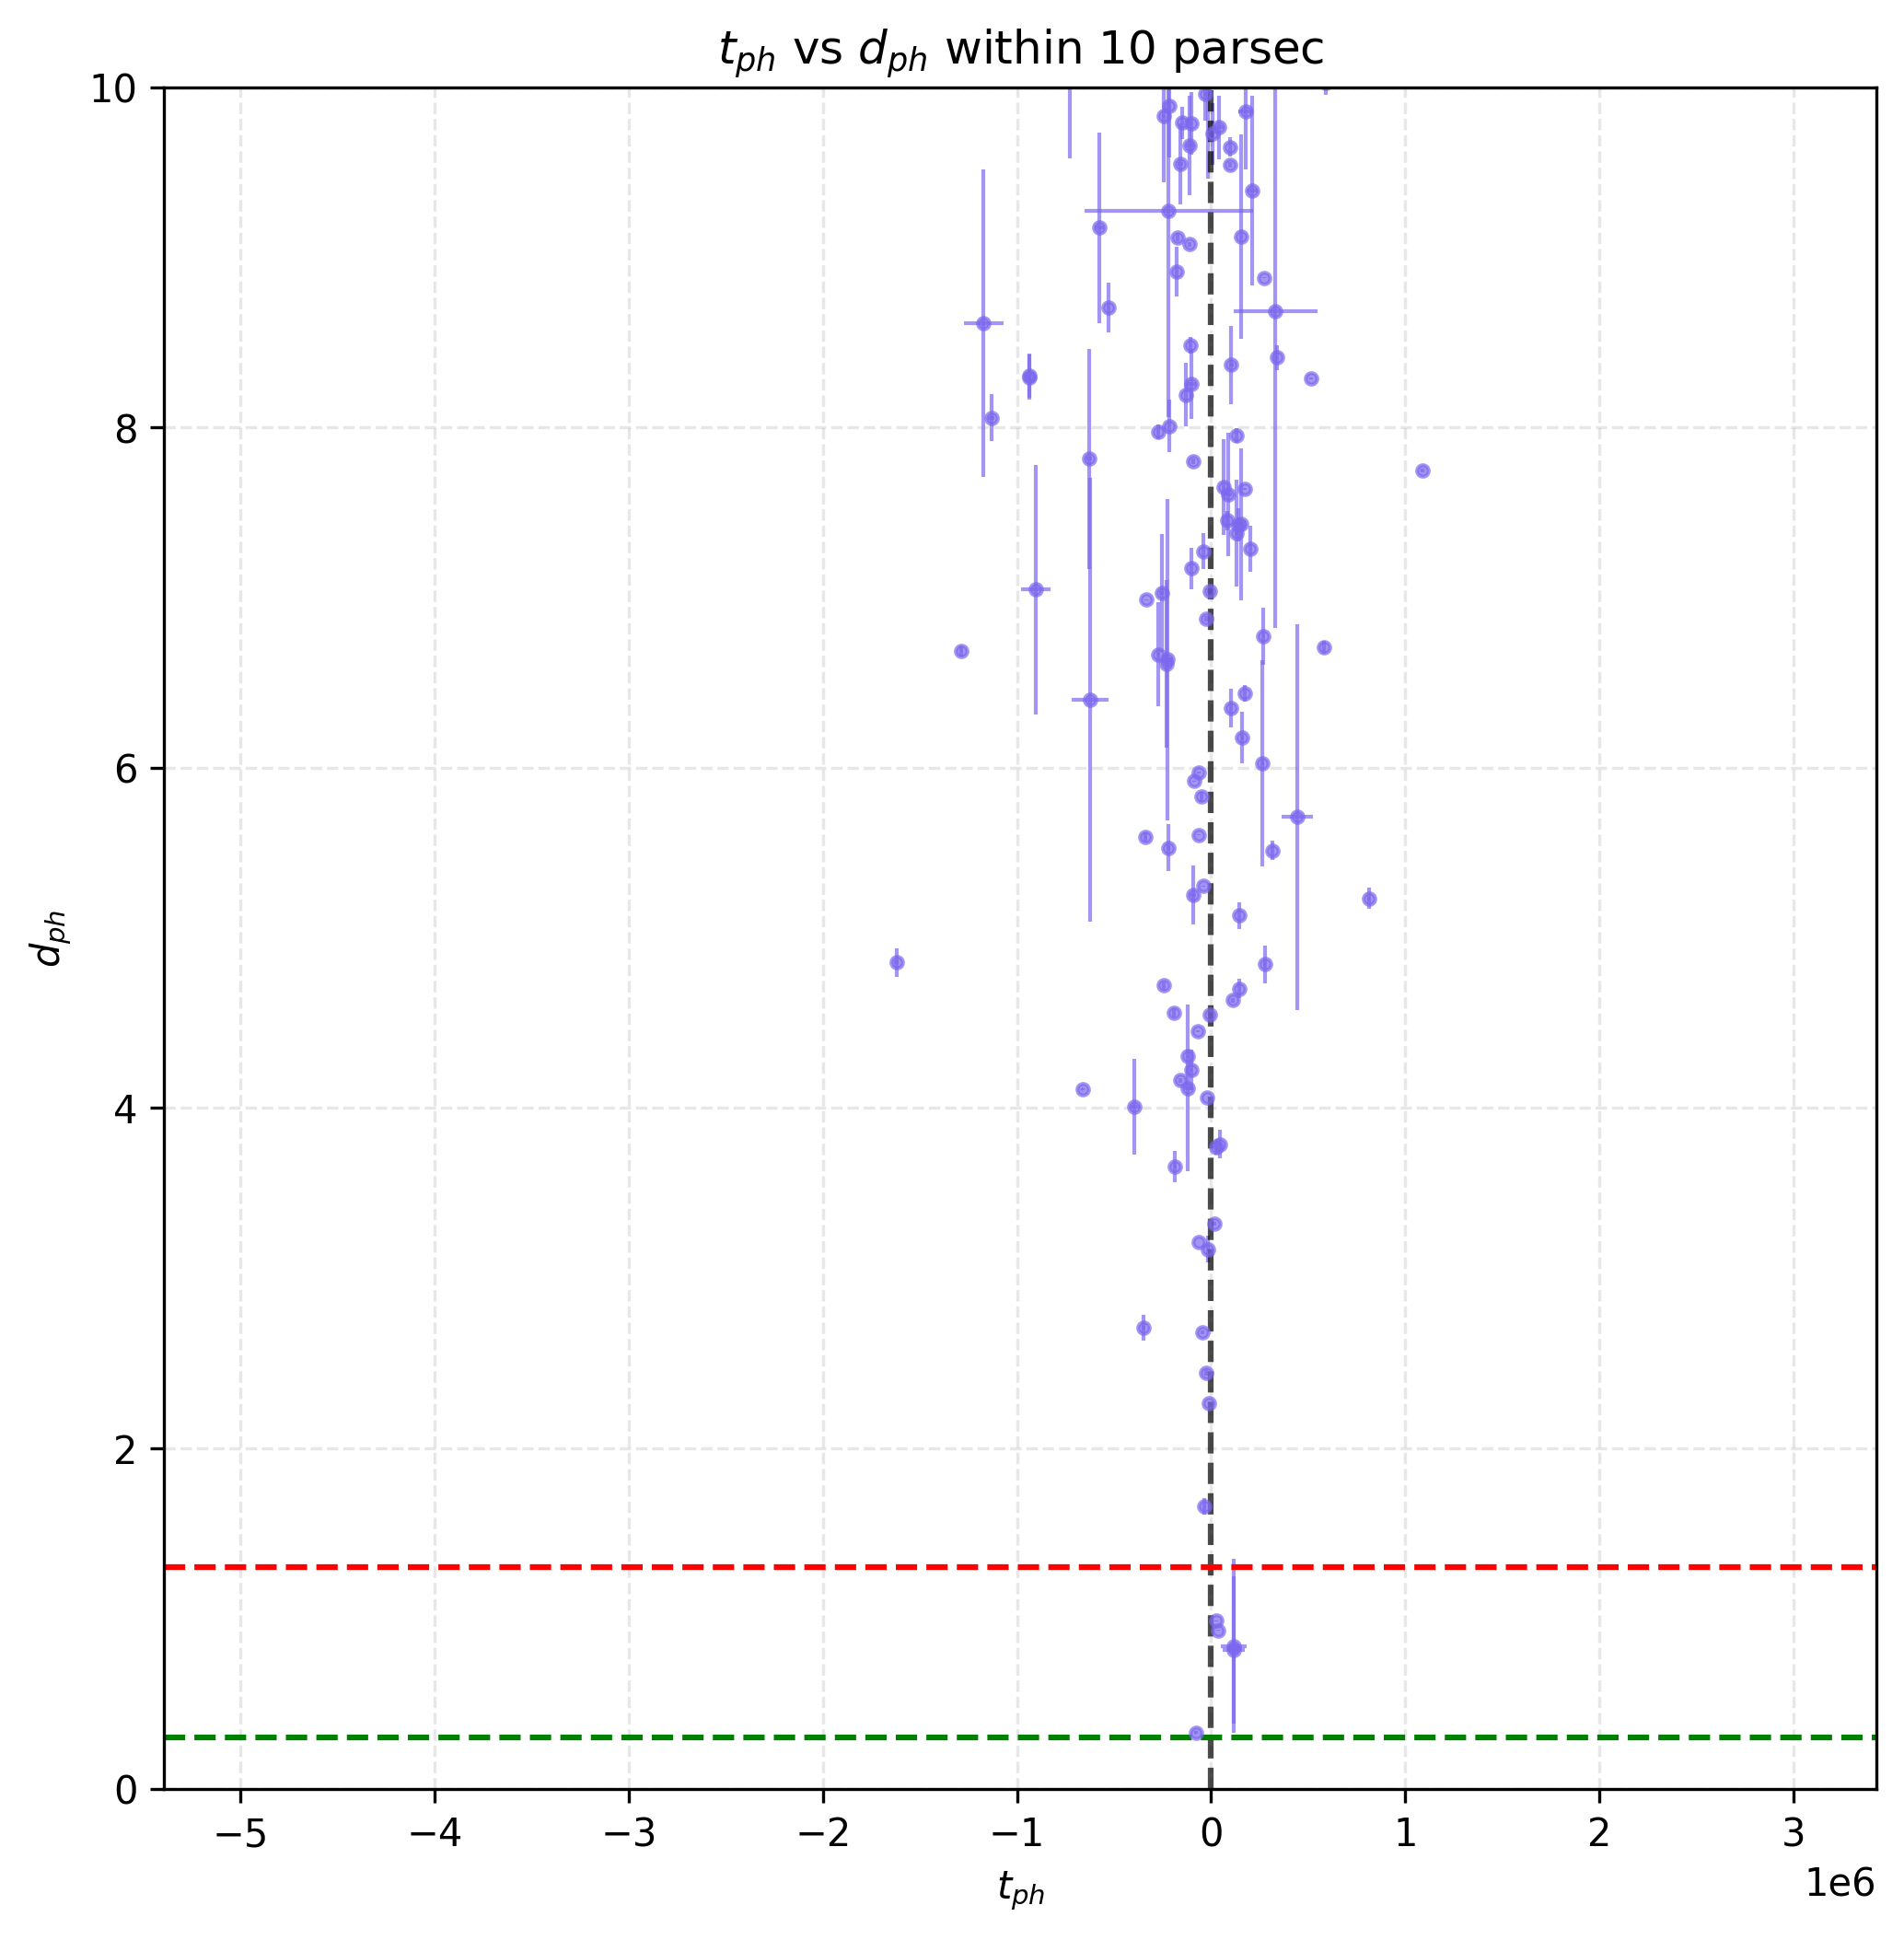

In [ ]:
# Plotting within 10 pc
fig = plt.figure(figsize=(8, 8), dpi = 300) 
large_2pc = (tphu_err < 2e7) & (dphu_err < 2)
plt.errorbar(tphu[large], dphu[large], xerr=tphu_err[large], yerr=dphu_err[large], fmt='.', color='mediumslateblue', alpha=0.7, linewidth=1)
plt.axvline(0, c = 'k', ls = '--', alpha = 0.7)
plt.title('$t_{ph}$ vs $d_{ph}$ within 10 parsec')
plt.xlabel('$t_{ph}$'); plt.ylabel('$d_{ph}$'); plt.grid(ls = '--', alpha = 0.3)
plt.axhline(proxima_centauri, c = 'r', ls = '--')
plt.axhline(oort_cloud, c = 'g', ls = '--')
plt.ylim(0,10)
plt.show()

In [ ]:
# Same code as above
## CREATE TABLE: finding the 10 closest stars to us
### Sort by tph within window
in10Myrs = (np.abs(tphu) <= 10e6) & np.isfinite(dphu) & np.isfinite(tphu) # using a filter of 10myr to us to make life easier
dphu_window = np.where(in10Myrs, dphu, np.inf) # filter array
iclose = np.argsort(dphu_window)[:10] # finding index of 10 closest

# Recalling these datasets as it's getting rewritten above for the 10 indices 
source_close  = data["SOURCE_ID_1"][iclose]
dph_close = dphu[iclose]
dpherr_close = dphu_err[iclose]
tph_close = tphu[iclose]
tpherr_close = tphu_err[iclose]
dclose = 1000 / plx[iclose]
derrclose = (parallax_err[iclose] / parallax[iclose]**2) * 1000

## Printing the table using pandas dataframes
table = pd.DataFrame({
    'No.' : np.arange(1, 11), # Numbering the objects
    'Gaia DR3 Source ID' : source_close, # Source ID
    'Current Dist (pc)' : np.round(dclose, 4), # Getting the current distance
    'Current Dist err (pc)' : np.round(derrclose, 4), # Getting the current distance
    'tph (yr)' : np.round(tph_close, 0).astype(int), # the time at perihelion and its assosicated error
    'tph err (yr)' : np.round(tpherr_close, 0).astype(int), # error
    'dph (pc)' : np.round(dph_close, 4), # the distance at perihelion and its associated error
    'dph err (pc)' : np.round(dpherr_close, 4)}) # error
table = table.set_index('No.')
print(table.to_string())

      Gaia DR3 Source ID  Current Dist (pc)  Current Dist err (pc)  tph (yr)  tph err (yr)  dph (pc)  dph err (pc)
No.                                                                                                               
1    1773485214494929536             6.7981                 0.0083    -79796           764    0.3300        0.0086
2     875071278432954240             9.2816                 0.0078    115936         58672    0.8139        0.4333
3    4968258979345754624             9.2816                 0.0126    117951         65986    0.8388        0.5107
4    4833306713154584704             3.1598                 0.0098     36399             4    0.9311        0.0002
5     116037371954842240             1.3020                 0.0173     26440             1    0.9852        0.0001
6     418077858975682304             1.9980                 0.0079    -34212          1211    1.6584        0.0468
7    2826640989657988992             2.4086                 0.0100    -14045    

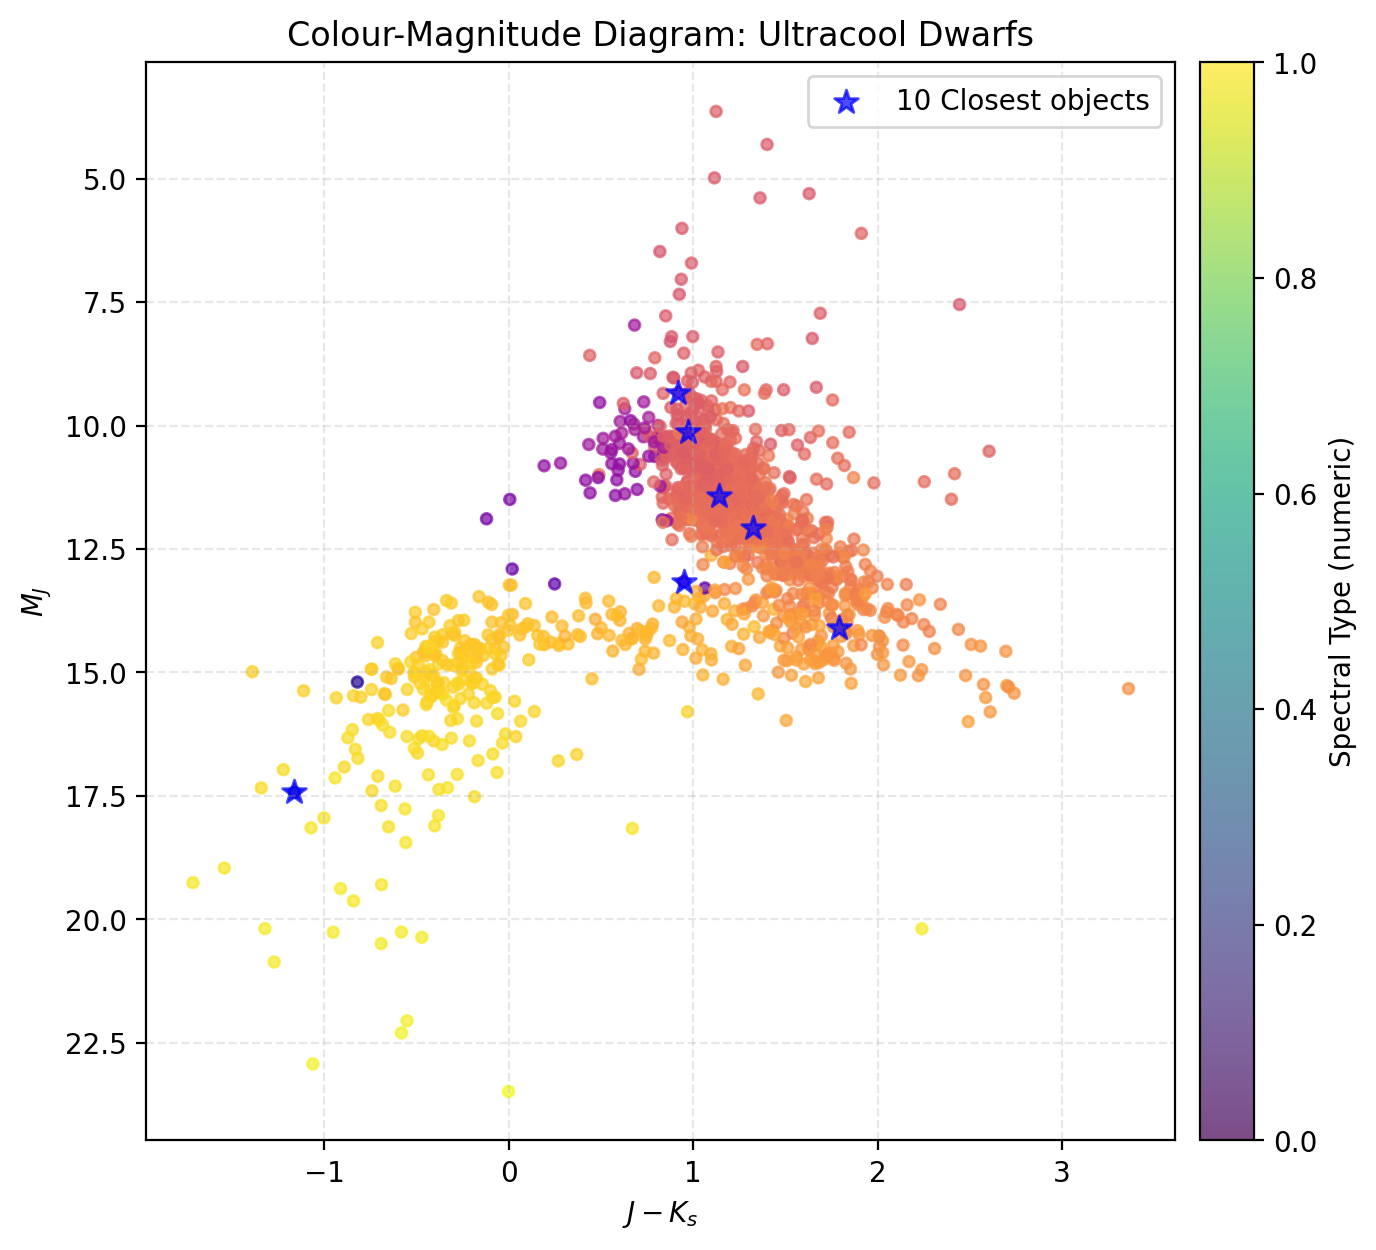

In [ ]:
# Colour mag diagram with 10 closest dwarfs overplotted
JKscm = JKs[iclose]
absJcm = absJ[iclose]
sptcm = spt[iclose]

fig, ax = plt.subplots(figsize=(8, 7), dpi=200)
sc = ax.scatter(JKs, absJ, c=spt, cmap='plasma', s=15, alpha=0.7)
sc = ax.scatter(JKscm, absJcm, c='b', s=80, alpha=0.7, marker = '*', label = "10 Closest objects")
cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label('Spectral Type (numeric)')
ax.invert_yaxis()
plt.xlabel(r'$J - K_s$')
plt.ylabel(r'$M_J$'); plt.legend()
plt.title('Colour-Magnitude Diagram: Ultracool Dwarfs')
plt.grid(ls='--', alpha=0.3);plt.show()